# Identification of factors

In this notebook, we use the already trained DRVI model on the immune dataset to show different ways to identify a factor. In summary we can:

- Identify based on available annotation
- Identify using GSEA
- Identify using Language models
- Looking into the annotation databases

**We always advise examination by a biologist or looking into the published litereture for validation of the identified processes.**

## Intro

In this notrbook, we assume that the user has already trained DRVI on Immune data.

Please refer to [General training and interpretability pipeline](./general_pipeline.html) tutorial.

## Contact

For questions and help requests, you can reach out in the [scverse discourse](https://discourse.scverse.org/).

If you found a bug, please use the [issue tracker](https://github.com/theislab/drvi/issues).

## Install

If you try DRVI on colab, next cell will install dependencies.

Please remove this part if your environment is already setup.

In [ ]:
import sys

# if branch is stable, will install via pypi, else will install from source
branch = "latest"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and branch == "stable":
    !pip install multigrate[tutorials]
elif IN_COLAB and branch != "stable":
    !pip install git+https://github.com/theislab/drvi.git#egg=drvi[tutorials]

## Imports

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt

import scvi
import drvi
from pathlib import Path
from drvi.model import DRVI
from drvi.utils.misc import hvg_batch

In [4]:
print("Last run with scvi-tools version:", scvi.__version__)
print("Last run with DRVI version:", drvi.__version__)

Last run with scvi-tools version: 1.4.1
Last run with DRVI version: 0.2.2


## Config

In [5]:
# Set this to false if you already trained your model and do not like to retrain.
overwrite = False
SEED = 1  # Set to None if you don't want to set seed

# Set input output directory
# We use tmp_io/ directory in the same place as this notebook. Update accordingly.
io_dir = Path("./tmp_io/drvi_immune_128/")
io_dir.mkdir(parents=True, exist_ok=True)
io_dir

PosixPath('tmp_io/drvi_immune_128')

## Load Data

In [6]:
# We already saved pre-processed data in previous notebook
adata = sc.read_h5ad("/home/icb/clara.sanchez/workspace/data/drvi_immune_128/adata_preprocesses.h5ad")

## Load DRVI ouputs

In [7]:
model_path = "/home/icb/clara.sanchez/workspace/data/drvi_immune_128/drvi_model"
embed_path = "/home/icb/clara.sanchez/workspace/data/drvi_immune_128/embed.h5ad"
traverse_adata_path = "/home/icb/clara.sanchez/workspace/data/drvi_immune_128/traverse_adata.h5ad"

model = DRVI.load(model_path, adata)
embed = sc.read_h5ad(embed_path)
traverse_adata = sc.read_h5ad(traverse_adata_path)

INFO     File /home/icb/clara.sanchez/workspace/data/drvi_immune_128/drvi_model/model.pt already downloaded        
INFO     DRVI: The model is trained with DRVI version 0.2.1.                                                       
INFO     DRVI: Updaging data setup config ...                                                                      
INFO     DRVI: Done updating data source registry. Loading in DRVI version 0.2.2.                                  
INFO     DRVI: Loading model from DRVI version 0.2.1.                                                              
INFO     DRVI: Modifying model args from 0.2.1 to 0.2.2 (no user action required)                                  
INFO     DRVI: Removing prior_init_obs from model args.                                                            
INFO     DRVI: Done updating model args. Loading in 0.2.2.                                                         
INFO     DRVI: The model has been initialized                           

## Identify based on available annotations

In this dataset we have annotations stored in `adata.obs["final_annotation"]`.

We first measure Scaled Mutual Information (SMI) between each latent dimension and each category using DRVI built-in functions.

In [ ]:
annot_col = "final_annotation"

### Specific Imports

In [9]:
import math
import networkx as nx
from drvi.utils.metrics import DiscreteDisentanglementBenchmark

### Helper functions

In [ ]:
def plot_packed_network(df, title_col='title', var_col='variable', val_col='value'):
    """
    Visualizes network with edge weights shown to 2 decimal places.
    """
    # Create Graph
    G = nx.from_pandas_edgelist(df, title_col, var_col, edge_attr=val_col)
    
    # Custom Grid Layout Logic
    pos = {}
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    cols = math.ceil(len(components)**0.5)
    
    for i, nodes in enumerate(components):
        sub_pos = nx.spring_layout(G.subgraph(nodes), weight=val_col, k=0.5, seed=42)
        r, c = divmod(i, cols)
        for n, (x, y) in sub_pos.items():
            pos[n] = (x + c * 3, y - r * 3)

    plt.figure(figsize=(14, 10))
    titles = set(df[title_col])
    
    # Draw Nodes & Edges
    nx.draw(G, pos, 
            with_labels=True, font_size=8, font_weight='bold', node_size=600,
            node_color=['#A0CBE2' if n in titles else '#FF9E9E' for n in G.nodes()],
            width=[d[val_col] * 4 for u, v, d in G.edges(data=True)], 
            edge_color='grey', alpha=0.6)
    
    # Draw Edge Labels (Weights rounded to 2 decimals)
    edge_labels = {(u, v): f"{d[val_col]:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
            
    plt.axis('off')
    plt.show()

### Code

In [11]:
# Remove vanished dimensions
embed_nv = embed[:, embed.var['vanished'] == False].copy()
embed_nv

AnnData object with n_obs × n_vars = 32484 × 61
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', '_scvi_batch', '_scvi_labels'
    var: 'original_dim_id', 'reconstruction_effect', 'order', 'max_value', 'mean', 'min', 'max', 'std', 'std_abs', 'title', 'vanished'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [12]:
benchmark = DiscreteDisentanglementBenchmark(
    embed_nv.X, dim_titles=embed_nv.var['title'], discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc", "SPN"], aggregation_methods=["LMS"],
)
benchmark.evaluate()
# You can optionally save benchmark object if you want.
# benchmark.save(filename)
# benchmark = DiscreteDisentanglementBenchmark.load(filename, embed_nv.X, dim_titles=embed_nv.var['title'], discrete_target=embed.obs["final_annotation"], metrics=["SMI-disc", "SPN"], aggregation_methods=["LMS"])

In [13]:
smi_similarity = benchmark.get_results_details()["SMI-disc"]
smi_similarity[:5]  # only showing 5 rows

,CD4+ T cells,CD8+ T cells,CD10+ B cells,CD14+ Monocytes,CD16+ Monocytes,CD20+ B cells,Erythrocytes,Erythroid progenitors,HSPCs,Megakaryocyte progenitors,Monocyte progenitors,Monocyte-derived dendritic cells,NK cells,NKT cells,Plasma cells,Plasmacytoid dendritic cells
title,,,,,,,,,,,,,,,,
DR 36,0.021124,0.007055,0.013579,0.005682,0.003340,0.006009,0.012808,0.025647,0.141675,0.147504,0.652945,0.023091,0.009346,0.006856,0.019912,0.010587
DR 49,0.058937,0.010312,0.003151,0.115108,0.019689,0.012800,0.006262,0.002189,0.002379,0.001219,0.001292,0.004543,0.008689,0.017035,0.859131,0.003900
DR 33,0.030350,0.011059,0.030578,0.021986,0.009531,0.011717,0.048552,0.468666,0.061815,0.370950,0.022623,0.007081,0.010243,0.011877,0.009066,0.005726
DR 38,0.017637,0.007678,0.008826,0.008149,0.012777,0.123699,0.004518,0.050416,0.004173,0.049967,0.008930,0.026165,0.005970,0.006707,0.018673,0.009291
DR 2,0.140299,0.080318,0.033397,0.761070,0.048512,0.084590,0.070976,0.036295,0.033788,0.033796,0.033385,0.107270,0.063494,0.064894,0.035367,0.038994


In [14]:
filtering_threshold = 0.5

top_matches = (
    smi_similarity.reset_index()
    .melt(id_vars='title', value_vars=smi_similarity.columns)
    .query("value >= @filtering_threshold")
    .reset_index(drop=True)
)
top_matches

,title,variable,value
0,DR 1,CD4+ T cells,0.535119
1,DR 41,CD10+ B cells,0.668039
2,DR 53,CD10+ B cells,0.773828
3,DR 31,CD10+ B cells,0.659314
4,DR 2,CD14+ Monocytes,0.761070
5,DR 3,CD14+ Monocytes,0.878655
6,DR 26,CD16+ Monocytes,0.661827
7,DR 9,CD16+ Monocytes,0.910748
8,DR 5,CD20+ B cells,0.758002
9,DR 7,CD20+ B cells,0.654006


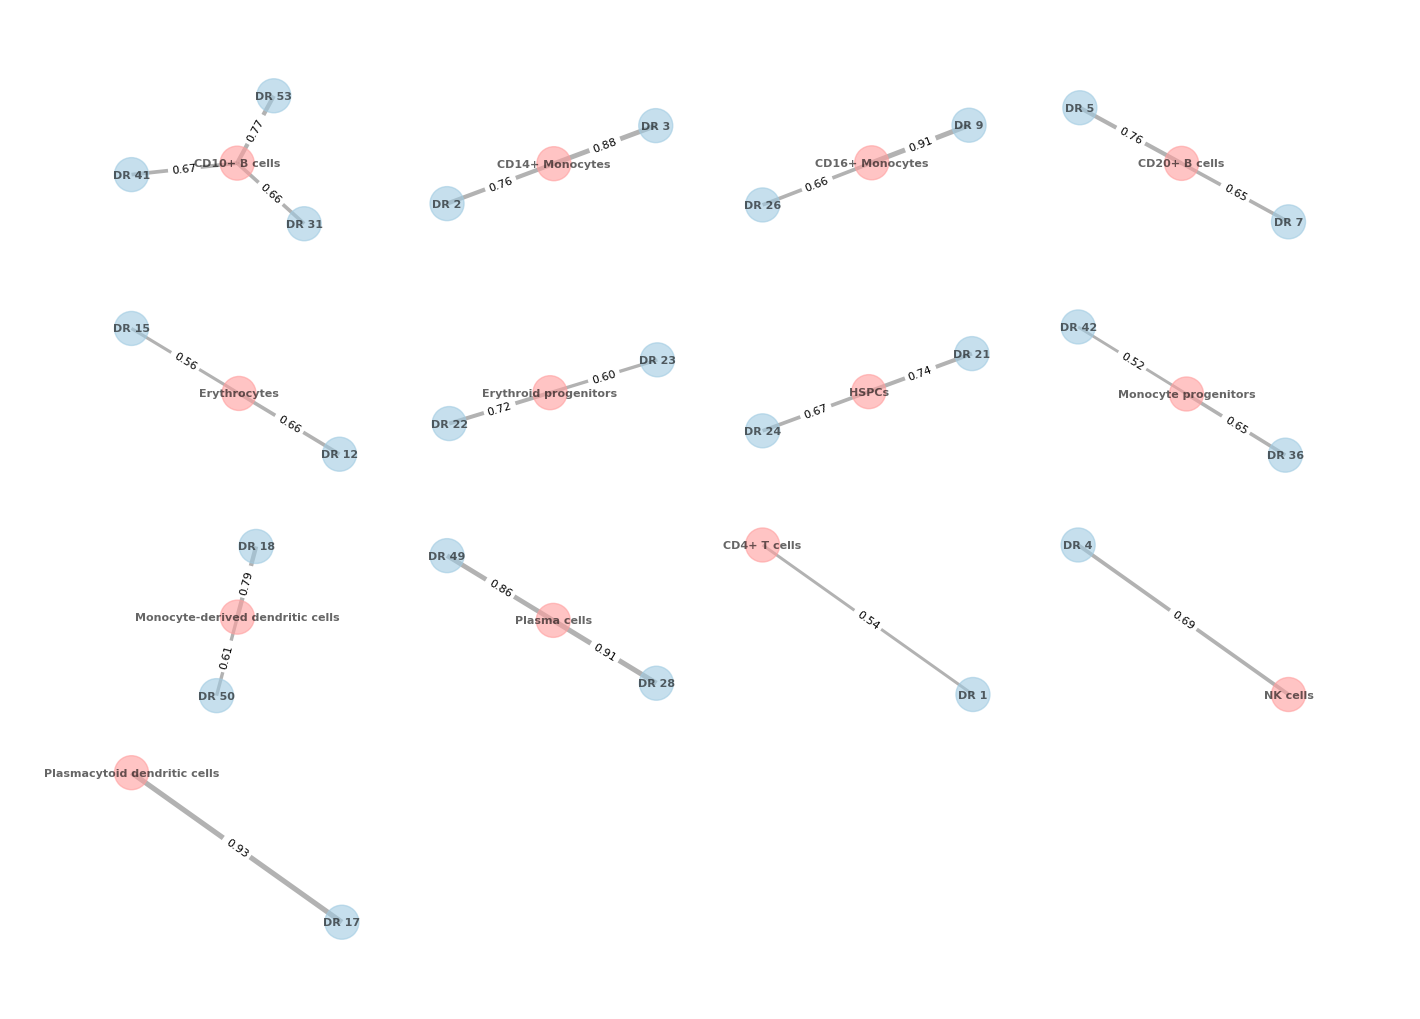

In [15]:
plot_packed_network(top_matches)

#### Heatmap

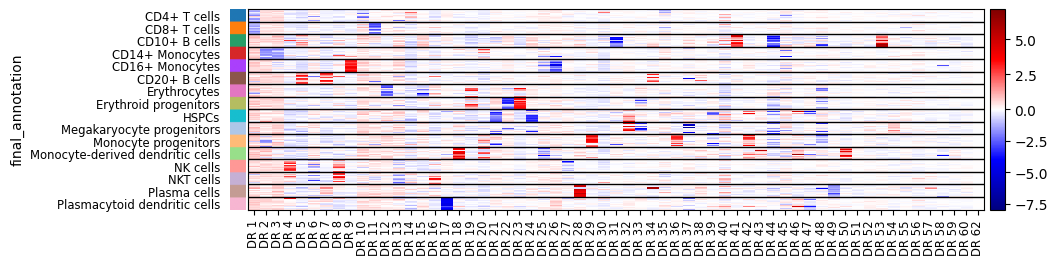

In [16]:
drvi.utils.pl.plot_latent_dims_in_heatmap(embed, "final_annotation", title_col="title")

It is possible to sort dimensions based on the top relevance with respect to a categoricals variable

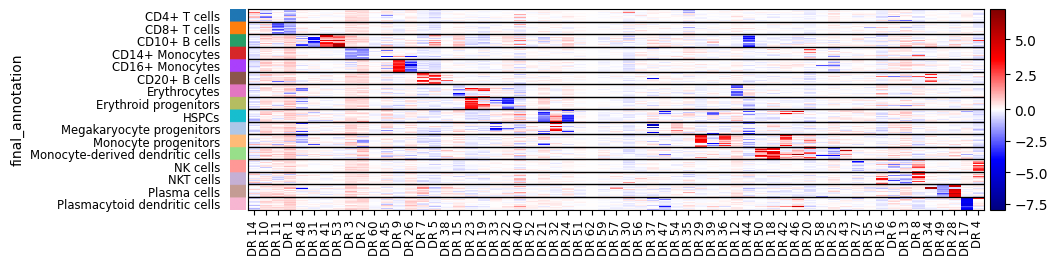

In [17]:
drvi.utils.pl.plot_latent_dims_in_heatmap(embed, "final_annotation", title_col="title", sort_by_categorical=True)

## Identification of programs

Once we identify the top relevant genes, we can determine some programs through supervised external information, such as:
- existing annotations
- examination by biologists
- gene-set enrichment analysis (GSEA)
- scientific literature
- automated tools based on language models

**Please refer to this tutorial for some tools that we found useful for identification of programs**

It is worth mentioning that since such supervised information is not given to the model, the quality of the derived signatures is neither affected nor biased by it. Unidentified processes with high gene scores are promising candidates for further literature search, additional analysis, and even experimental design.

1. Input: 
-Gene list?
-Ranked list?
Expression Correlation with known Zelltype Markers
2. Reference Databases: 
-Classic Datatabases: Gene Ontology, Reactome, MSigDB? 
-Celltype specific Data (Cell Typist)
-LLMs: gsai?
3. Annotation Method:
-Over-representation
-Regressions based: How well does a set of genes explain a factor




# Exploration Roadmap: DRVI Factor Annotation Pipeline

This roadmap outlines the systematic evaluation of tools for annotating latent factors. The goal is to move from abstract dimensions to interpretable biological processes using the immune dataset as a pilot.

## General Roadmap Settings


### Shared Imports

In [18]:
import hashlib
import re
from collections import Counter
from pathlib import Path
from scipy.spatial.distance import cosine as cosine_dist

import logging

import blitzgsea as blitz
import celltypist
import decoupler as dc
import gseapy
import numpy as np
import pandas as pd
import seaborn as sns
from celltypist import models
from gprofiler import GProfiler
from statsmodels.stats.multitest import multipletests

### General Configurations and Settings

#### Gene preprocessing

In [ ]:
GENE_CASE = "upper"  # Normalize gene symbols to uppercase for cross-database matching
TOP_N = 300 # Number of top-ranked genes per factor used as input for ORA tools (g:Profiler)
FDR = 0.05 # False Discovery Rate threshold for significance across all tools

In [20]:
print(gseapy.get_library_name())

['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

In [21]:
from gprofiler import GProfiler
gp_meta = GProfiler(return_dataframe=True)
res = gp_meta.profile(
    organism="hsapiens",
    query=["TP53", "BRCA1", "MYC", "CD3E", "CD19", "CD14", "FCGR3A", "HBA1"],
    user_threshold=1.0,   # no filtering — return everything
    no_evidences=True,
)
print(sorted(res["source"].unique().tolist()))

['CORUM', 'GO:BP', 'GO:CC', 'GO:MF', 'HP', 'HPA', 'KEGG', 'MIRNA', 'REAC', 'TF', 'WP']


In [22]:
enrichr_libs = gseapy.get_library_name()
print(f"Total Enrichr libraries: {len(enrichr_libs)}")
print("Top 20:", enrichr_libs[:20])

Total Enrichr libraries: 225
Top 20: ['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020']


In [23]:
# Lists all resources available via OmniPath
resources = dc.op.show_resources()
print(dc.op.show_resources().to_string())

                    name     license
0               Adhesome  commercial
1              Almen2009  commercial
2             Baccin2019    academic
3           CORUM_Funcat    academic
4               CORUM_GO    academic
5                   CPAD        None
6                   CSPA  commercial
7          CSPA_celltype  commercial
8          CancerDrugsDB    academic
9       CancerGeneCensus    academic
10             CancerSEA    academic
11              CellCall  commercial
12  CellCellInteractions  non_profit
13            CellChatDB  commercial
14    CellChatDB_complex  commercial
15           CellPhoneDB  commercial
16   CellPhoneDB_complex  commercial
17            CellTalkDB  commercial
18            CellTypist  commercial
19             Cellinker    academic
20     Cellinker_complex    academic
21                ComPPI  commercial
22               CytoSig  non_profit
23                 DGIdb  commercial
24              DisGeNet    academic
25               EMBRACE  commercial
2

In [ ]:
# For Transcription Factors (CollecTRI/DoRothEA)
print("Common Decoupler / OmniPath Resources:")
# You can view the specific collections available for the 'get_resource' function
# Note: These are often accessed directly via functions like dc.get_collectri() 
# or dc.get_progeny()
print(["CollecTRI", "DoRothEA", "PROGENy", "MSigDB", "OmniPath"])

Common Decoupler / OmniPath Resources:
['CollecTRI', 'DoRothEA', 'PROGENy', 'MSigDB', 'OmniPath']


In [25]:
# ---------------------------------------------------------------------------
# CellTypist
# ---------------------------------------------------------------------------
CT_CORR_THRESHOLD = 0.40 # Minimum Pearson correlation between factor and cell-type probability
CT_SPEC_THRESHOLD = 0.10 # Minimum specificity (gap between best and second-best correlation)

# ---------------------------------------------------------------------------
# GSEA tools (blitzgsea / gseapy)
# ---------------------------------------------------------------------------
GSEA_DB = "Azimuth_Cell_Types_2021"  # Any gseapy-compatible library name, e.g. "MSigDB_Hallmark_2020", "GO_Biological_Process_2023", "Azimuth_Cell_Types_2021"
GSEAPY_MIN_SIZE = 10
GSEAPY_MAX_SIZE = 500
GSEAPY_PERMUTATIONS = 1000
BLITZGSEA_PROCESSES = 4

# ---------------------------------------------------------------------------
# g:Profiler
# ---------------------------------------------------------------------------
GP_ORGANISM = "hsapiens"
GP_SOURCES = None  # Any list of g:Profiler sources, e.g. ["GO:BP", "REAC", "MSigDB_Hallmark_2020"]. Set to None to use all sources.
GP_USER_THRESHOLD = 0.05
GP_ORDERED = True

# ---------------------------------------------------------------------------
# decoupler
# ---------------------------------------------------------------------------
DC_ORGANISM = "human"
DC_GENESET = "progeny"  # Any OmniPath resource name, e.g. "PanglaoDB", "CellTypist". Set to None if using custom network.
DC_METHODS = ["ulm", "mlm", "zscore"]
DC_USE_CONSENSUS = True
DC_PRIMARY_METHOD = "ulm"
DC_TMIN = 5

# ---------------------------------------------------------------------------
# Input harmonization
# ---------------------------------------------------------------------------
USE_EMBED_FACTOR_NAMES = True
FACTOR_NAME_COL = "title"

# ---------------------------------------------------------------------------
# Tool registry  (toggle tools on/off for experiment runs)
# ---------------------------------------------------------------------------
CELLTYPE_TOOLS = ["atlas", "celltypist"]
BIOPROC_TOOLS  = ["blitzgsea", "gseapy", "gprofiler", "decoupler"]


# ---------------------------------------------------------------------------
# DB_NAME_MAP
# Canonical database name → tool-specific string.
# None means that tool does not support that database — the loop skips it.
# Tool name strings verified against actual tool outputs (2026-03-06).
#
# blitzgsea / gseapy : Enrichr API names (gseapy.get_library_name())
# gprofiler          : g:Profiler source codes (gp.profile() 'source' column)
# decoupler          : dc.op.show_resources() names OR dedicated dc.op.<func>() names
# ---------------------------------------------------------------------------
DB_NAME_MAP = {
    # ── Cell type annotation ─────────────────────────────────────────────────
    "Azimuth_2023":              {"blitzgsea": "Azimuth_2023",              "gseapy": "Azimuth_2023",              "gprofiler": None, "decoupler": None},
    "Azimuth_Cell_Types_2021":   {"blitzgsea": "Azimuth_Cell_Types_2021",   "gseapy": "Azimuth_Cell_Types_2021",   "gprofiler": None, "decoupler": None},
    "CellMarker_2024":           {"blitzgsea": "CellMarker_2024",           "gseapy": "CellMarker_2024",           "gprofiler": None, "decoupler": None},
    "CellMarker_Augmented_2021": {"blitzgsea": "CellMarker_Augmented_2021", "gseapy": "CellMarker_Augmented_2021", "gprofiler": None, "decoupler": None},
    "PanglaoDB_Augmented_2021":  {"blitzgsea": "PanglaoDB_Augmented_2021",  "gseapy": "PanglaoDB_Augmented_2021",  "gprofiler": None, "decoupler": "PanglaoDB"},
    "Tabula_Sapiens":            {"blitzgsea": "Tabula_Sapiens",            "gseapy": "Tabula_Sapiens",            "gprofiler": None, "decoupler": None},
    "Tabula_Muris":              {"blitzgsea": "Tabula_Muris",              "gseapy": "Tabula_Muris",              "gprofiler": None, "decoupler": None},
    "Descartes_Cell_Types_and_Tissue_2021": {"blitzgsea": "Descartes_Cell_Types_and_Tissue_2021", "gseapy": "Descartes_Cell_Types_and_Tissue_2021", "gprofiler": None, "decoupler": None},
    # ── Biological process — core pathways ───────────────────────────────────
    "GO_Biological_Process_2025": {"blitzgsea": "GO_Biological_Process_2025", "gseapy": "GO_Biological_Process_2025", "gprofiler": "GO:BP", "decoupler": None},
    "GO_Cellular_Component_2025": {"blitzgsea": "GO_Cellular_Component_2025", "gseapy": "GO_Cellular_Component_2025", "gprofiler": "GO:CC", "decoupler": None},
    "GO_Molecular_Function_2025": {"blitzgsea": "GO_Molecular_Function_2025", "gseapy": "GO_Molecular_Function_2025", "gprofiler": "GO:MF", "decoupler": None},
    "Reactome_Pathways_2024":     {"blitzgsea": "Reactome_Pathways_2024",     "gseapy": "Reactome_Pathways_2024",     "gprofiler": "REAC",  "decoupler": None},
    "MSigDB_Hallmark_2020":       {"blitzgsea": "MSigDB_Hallmark_2020",       "gseapy": "MSigDB_Hallmark_2020",       "gprofiler": None,    "decoupler": None},
    "KEGG_2021_Human":            {"blitzgsea": "KEGG_2021_Human",            "gseapy": "KEGG_2021_Human",            "gprofiler": None,    "decoupler": "KEGG"},
    "KEGG_2026":                  {"blitzgsea": "KEGG_2026",                  "gseapy": "KEGG_2026",                  "gprofiler": "KEGG",  "decoupler": "KEGG"},
    "WikiPathways_2024_Human":    {"blitzgsea": "WikiPathways_2024_Human",    "gseapy": "WikiPathways_2024_Human",    "gprofiler": "WP",    "decoupler": None},
    "BioCarta_2016":              {"blitzgsea": "BioCarta_2016",              "gseapy": "BioCarta_2016",              "gprofiler": None,    "decoupler": None},
    "BioPlanet_2019":             {"blitzgsea": "BioPlanet_2019",             "gseapy": "BioPlanet_2019",             "gprofiler": None,    "decoupler": None},
    # ── Biological process — regulatory ──────────────────────────────────────
    # DoRothEA and CollecTRI use dedicated dc.op functions, not dc.op.resource()
    "DoRothEA":  {"blitzgsea": None, "gseapy": None, "gprofiler": None, "decoupler": "DoRothEA"},
    "CollecTRI": {"blitzgsea": None, "gseapy": None, "gprofiler": None, "decoupler": "CollecTRI"},
    "PROGENy":   {"blitzgsea": None, "gseapy": None, "gprofiler": None, "decoupler": "PROGENy"},
    # ── Human Phenotype Ontology ──────────────────────────────────────────────
    "Human_Phenotype_Ontology": {"blitzgsea": "Human_Phenotype_Ontology", "gseapy": "Human_Phenotype_Ontology", "gprofiler": "HP", "decoupler": None},
    # ── Human Protein Atlas ───────────────────────────────────────────────────
    "Human_Protein_Atlas": {"blitzgsea": None, "gseapy": None, "gprofiler": "HPA", "decoupler": None},
}

# ---------------------------------------------------------------------------
# LIBRARIES — drives the benchmark loop.
# Panels: Core_Biology_DRVI and Cell_Type_Annotation
# (from curated gene_set_libraries_final_with_recommendations.xlsx)
# ---------------------------------------------------------------------------
LIBRARIES = [
    # ── Cell Type Annotation panel ───────────────────────────────────────────
    # Azimuth (most recent 2023 version preferred)
    {"db_name": "Azimuth_2023",              "tool": "blitzgsea", "domain": "CellType", "min_size": 5, "max_size": 500},
    {"db_name": "Azimuth_2023",              "tool": "gseapy",    "domain": "CellType", "min_size": 5, "max_size": 500},
    # CellMarker (2024 version preferred, augmented 2021 as fallback)
    {"db_name": "CellMarker_2024",           "tool": "blitzgsea", "domain": "CellType", "min_size": 5, "max_size": 500},
    {"db_name": "CellMarker_2024",           "tool": "gseapy",    "domain": "CellType", "min_size": 5, "max_size": 500},
    # PanglaoDB — also available in decoupler
    {"db_name": "PanglaoDB_Augmented_2021",  "tool": "blitzgsea", "domain": "CellType", "min_size": 5, "max_size": 500},
    {"db_name": "PanglaoDB_Augmented_2021",  "tool": "gseapy",    "domain": "CellType", "min_size": 5, "max_size": 500},
    {"db_name": "PanglaoDB_Augmented_2021",  "tool": "decoupler", "domain": "CellType", "min_size": 5, "max_size": 500},
    # Tabula Sapiens (human atlas)
    {"db_name": "Tabula_Sapiens",            "tool": "blitzgsea", "domain": "CellType", "min_size": 5, "max_size": 500},
    {"db_name": "Tabula_Sapiens",            "tool": "gseapy",    "domain": "CellType", "min_size": 5, "max_size": 500},
    # Descartes Atlas
    {"db_name": "Descartes_Cell_Types_and_Tissue_2021", "tool": "blitzgsea", "domain": "CellType", "min_size": 5, "max_size": 500},
    {"db_name": "Descartes_Cell_Types_and_Tissue_2021", "tool": "gseapy",    "domain": "CellType", "min_size": 5, "max_size": 500},

    # ── Core Biology DRVI panel ───────────────────────────────────────────────
    # GO Biological Process — g:Profiler is primary source per curation sheet
    {"db_name": "GO_Biological_Process_2025", "tool": "gprofiler", "domain": "BioProc", "min_size": 10, "max_size": 500},
    {"db_name": "GO_Biological_Process_2025", "tool": "gseapy",    "domain": "BioProc", "min_size": 10, "max_size": 500},
    {"db_name": "GO_Biological_Process_2025", "tool": "blitzgsea", "domain": "BioProc", "min_size": 10, "max_size": 500},
    # GO Cellular Component
    {"db_name": "GO_Cellular_Component_2025", "tool": "gprofiler", "domain": "BioProc", "min_size": 10, "max_size": 500},
    {"db_name": "GO_Cellular_Component_2025", "tool": "gseapy",    "domain": "BioProc", "min_size": 10, "max_size": 500},
    # GO Molecular Function
    {"db_name": "GO_Molecular_Function_2025", "tool": "gprofiler", "domain": "BioProc", "min_size": 10, "max_size": 500},
    {"db_name": "GO_Molecular_Function_2025", "tool": "gseapy",    "domain": "BioProc", "min_size": 10, "max_size": 500},
    # Reactome — g:Profiler and Enrichr both supported
    {"db_name": "Reactome_Pathways_2024",     "tool": "gprofiler", "domain": "BioProc", "min_size": 10, "max_size": 500},
    {"db_name": "Reactome_Pathways_2024",     "tool": "gseapy",    "domain": "BioProc", "min_size": 10, "max_size": 500},
    {"db_name": "Reactome_Pathways_2024",     "tool": "blitzgsea", "domain": "BioProc", "min_size": 10, "max_size": 500},
    # MSigDB Hallmark — Enrichr only (no decoupler Hallmark-only resource)
    {"db_name": "MSigDB_Hallmark_2020",       "tool": "gseapy",    "domain": "BioProc", "min_size": 10, "max_size": 500},
    {"db_name": "MSigDB_Hallmark_2020",       "tool": "blitzgsea", "domain": "BioProc", "min_size": 10, "max_size": 500},
    # KEGG 2026 — most current; g:Profiler + Enrichr + decoupler all supported
    {"db_name": "KEGG_2026",                  "tool": "gprofiler", "domain": "BioProc", "min_size": 10, "max_size": 500},
    {"db_name": "KEGG_2026",                  "tool": "gseapy",    "domain": "BioProc", "min_size": 10, "max_size": 500},
    {"db_name": "KEGG_2026",                  "tool": "blitzgsea", "domain": "BioProc", "min_size": 10, "max_size": 500},
    {"db_name": "KEGG_2026",                  "tool": "decoupler", "domain": "BioProc", "min_size": 10, "max_size": 500},
    # WikiPathways 2024
    {"db_name": "WikiPathways_2024_Human",    "tool": "gprofiler", "domain": "BioProc", "min_size": 10, "max_size": 500},
    {"db_name": "WikiPathways_2024_Human",    "tool": "gseapy",    "domain": "BioProc", "min_size": 10, "max_size": 500},
    {"db_name": "WikiPathways_2024_Human",    "tool": "blitzgsea", "domain": "BioProc", "min_size": 10, "max_size": 500},
    # Regulatory networks — decoupler only
    # CollecTRI: TF → target gene regulons (recommended over DoRothEA for immune)
    {"db_name": "CollecTRI", "tool": "decoupler", "domain": "BioProc", "min_size": 5, "max_size": 500},
    # DoRothEA: TF regulons with confidence levels A-C
    {"db_name": "DoRothEA",  "tool": "decoupler", "domain": "BioProc", "min_size": 5, "max_size": 500},
    # PROGENy: pathway activity (cancer-oriented, limited immune value but included for completeness)
    {"db_name": "PROGENy",   "tool": "decoupler", "domain": "BioProc", "min_size": 5, "max_size": 500},
    # Human Phenotype Ontology — g:Profiler primary
    {"db_name": "Human_Phenotype_Ontology", "tool": "gprofiler", "domain": "BioProc", "min_size": 5, "max_size": 500},
    {"db_name": "Human_Phenotype_Ontology", "tool": "gseapy",    "domain": "BioProc", "min_size": 5, "max_size": 500},
    # Human Protein Atlas — g:Profiler only
    {"db_name": "Human_Protein_Atlas",      "tool": "gprofiler", "domain": "BioProc", "min_size": 5, "max_size": 500},
]
DB_CONFIGS = pd.DataFrame(LIBRARIES)


### Caching

In [26]:
# Result caching: avoids re-running expensive enrichment steps on every iteration.
# Usage: wrap any run block with cache_load / cache_save.
cache_dir = io_dir / "cache"
cache_dir.mkdir(parents=True, exist_ok=True)

#Load a cached DataFrame if it exists and overwrite=False.
def cache_load(name):
    p = cache_dir / f"{name}.pkl"
    if p.exists() and not overwrite:
        print(f"[cache] loaded '{name}'")
        return pd.read_pickle(p)
    return None

#Persist a DataFrame to disk.
def cache_save(name, df):
    p = cache_dir / f"{name}.pkl"
    df.to_pickle(p)
    print(f"[cache] saved '{name}'")
    return df


### Data Preparation
Works directly with existing session objects:
- `adata`, `embed`, `traverse_adata`
and prepares:
- `pos_df`, `neg_df` (genes x factors)
- aligned cell indices for `adata` and `embed_full`

In [27]:
#global background genes
adata_full = sc.read_h5ad("/home/icb/clara.sanchez/data/drvi_immune_128/immune_all.h5ad")
ALL_GENES = adata_full.var_names.astype(str).str.strip()

if GENE_CASE == "upper":
    ALL_GENES = ALL_GENES.str.upper()

ALL_GENES = pd.Index(ALL_GENES).drop_duplicates().tolist()
print(f"ALL_GENES: {len(ALL_GENES)} genes")



ALL_GENES: 12303 genes


In [28]:
# Always reload the full (unfiltered) embedding from disk so that
# re-running this cell produces the same result every time
embed_full = sc.read_h5ad(embed_path)

# Ensure adata and embed share the same cells (obs_names)
common_cells = adata.obs_names.intersection(embed_full.obs_names)
adata = adata[common_cells].copy()
embed_full = embed_full[common_cells].copy()
print(f"Synced cells: {adata.n_obs}")

# Ensure vanished info exists
if "vanished" not in embed_full.var.columns:
    drvi.utils.tl.set_latent_dimension_stats(model, embed_full, vanished_threshold=0.1)

# Remove vanished dimensions
mask = ~embed_full.var["vanished"].astype(bool).values
embed = embed_full[:, mask].copy()
print(f"Factors after filtering: {embed.n_vars}")

#  Factor IDs for downstream analysis
factor_id_col = "title" if "title" in embed.var.columns else "original_dim_id"
factor_ids = embed.var[factor_id_col].astype(str).tolist()
drvi_factors = pd.DataFrame(embed.X, index=embed.obs_names, columns=factor_ids)

# # Extract per-gene effect scores from the traverse analysis
# pos_df/neg_df: genes x factors matrices of traverse effect scores
# These capture how strongly each gene responds when a latent factor is traversed
# in the positive or negative direction (directional gene-factor relationships)
pos_df = traverse_adata.varm["combined_score_traverse_effect_pos"].copy()
neg_df = traverse_adata.varm["combined_score_traverse_effect_neg"].copy()

if pos_df.shape[1] == len(mask):
    pos_df = pos_df.iloc[:, mask].copy()
    neg_df = neg_df.iloc[:, mask].copy()

pos_df.columns = factor_ids
neg_df.columns = factor_ids

Synced cells: 32484
Factors after filtering: 61


#### Helper functions

In [29]:
# Map each factor to its top annotation label and SMI score (from smi_similarity).
# This is merged into each tool's results table to show the known cell-type context.
x = smi_similarity.apply(pd.to_numeric, errors="coerce")
x.index = x.index.astype(str)

annot_map = pd.DataFrame({
    "Factor": x.index,
    "Annot_Label": x.idxmax(axis=1).astype(str).values,
    "Annot_SMI": x.max(axis=1).round(3).values,
})
annot_map.head()

,Factor,Annot_Label,Annot_SMI
0,DR 36,Monocyte progenitors,0.653
1,DR 49,Plasma cells,0.859
2,DR 33,Erythroid progenitors,0.469
3,DR 38,CD20+ B cells,0.124
4,DR 2,CD14+ Monocytes,0.761


### Shared Preprocessing

In [30]:
# Prepare ranked gene lists and top-N gene sets for enrichment analysis
# Input:  genes x factors score matrix, number of top genes, case normalization.
# Output: (std, ranked, top) where
        # - std:    standardized scores DataFrame (genes x factors)
        # - ranked: dict of all genes sorted by descending score per factor (input for GSEA-style tools: BlitzGSEA, GSEApy)
        # - top:    dict of top_n gene symbols per factor (input for ORA-style tools: g:Profiler)

#Normalize gene symbols and resolve duplicates
# Input:  DataFrame with gene symbols as index, factors as columns.
# Output: DataFrame with cleaned index (uppercased if gene_case="upper"), duplicate genes merged by taking the max score per factor.


def build_inputs(df, top_n, gene_case="upper", all_genes=ALL_GENES):
    """Standardize gene symbols and build enrichment inputs from a genes × factors score matrix.

    Parameters
    ----------
    df : DataFrame
        Raw genes × factors score matrix (e.g. pos_df / neg_df from traverse analysis).
    top_n : int
        Number of top-ranked genes to include in the ORA (g:Profiler) query set.
    gene_case : str
        "upper" to uppercase gene symbols for cross-database matching.
    all_genes : list
        Background gene universe; rows are reindexed to this set (missing → NaN).

    Returns
    -------
    std : DataFrame
        Standardized genes × factors scores (duplicates merged by max).
    ranked : dict
        {factor: Series of all genes sorted by descending score} – input for GSEA tools.
    top : dict
        {factor: list of top_n gene symbols} – input for ORA tools (g:Profiler).
    """
    std = df.copy()
    std.index = std.index.astype(str).str.strip()
    if gene_case == "upper":
        std.index = std.index.str.upper()
    # Duplicate gene symbols are collapsed by taking the max score per factor.
    std = std.groupby(std.index).max()

    if all_genes is not None:
        idx = pd.Index(pd.Series(all_genes).astype(str)).drop_duplicates()
        # Reindex to the background universe; genes absent from df become NaN
        # (not zero, to avoid inflating GSEA null distributions).
        std = std.reindex(idx)

    # Only genes with real scores are included in ranked lists.
    ranked = {c: std[c].dropna().sort_values(ascending=False) for c in std.columns}
    top    = {c: ranked[c].head(top_n).index.tolist()          for c in std.columns}
    return std, ranked, top

In [31]:
# Build standardized score matrices and ranked/top gene lists for both directions.
# pos_std/neg_std: genes x factors (standardized), used by decoupler.
# pos_ranked/neg_ranked: full ranked gene lists per factor, used by BlitzGSEA and GSEApy.
# pos_top/neg_top: top-N gene lists per factor, used by g:Profiler.
pos_std, pos_ranked, pos_top = build_inputs(pos_df, TOP_N, GENE_CASE, ALL_GENES)
neg_std, neg_ranked, neg_top = build_inputs(neg_df, TOP_N, GENE_CASE, ALL_GENES)
factor_ids = list(pos_std.columns)

print(f"Factors: {len(factor_ids)}")

Factors: 61


In [ ]:
 # Summarise background gene count and enrichment input shapes for a quick sanity check.
print(f"ALL_GENES (background): {len(ALL_GENES)}")

# Build combined ranked-input dict: "{factor}_pos" / "{factor}_neg" → ranked Series
ranked_inputs = {
    f"{fac}_{direction}": series
    for fac in factor_ids
    for direction, series in [("pos", pos_ranked[fac]), ("neg", neg_ranked[fac])]
 }
print(f"Ranked inputs (factor × direction): {len(ranked_inputs)}")

k = next(iter(pos_top))
print(f"[g:Profiler] query genes (Top-N, pos) for {k}: {len(pos_top[k])}")
print(f"[g:Profiler] background genes: {len(ALL_GENES)}")

mat = pos_std.T.reindex(columns=ALL_GENES, fill_value=0.0)
print(f"[decoupler] matrix shape (pos): {mat.shape}  # (factors, genes)")

ALL_GENES (background): 12303
Ranked inputs (factor × direction): 122
[g:Profiler] query genes (Top-N, pos) for DR 36: 300
[g:Profiler] background genes: 12303
[decoupler] matrix shape (pos): (61, 12303)  # (factors, genes)


### Helper Function Summary

In [33]:
# Helper: strip FactorDir to base factor (e.g. "DR 36_pos" -> "DR 36")
def strip_factor(x):
    return (pd.Series(x).astype(str)
            .str.replace(r"_(pos|neg)$", "", regex=True)
            .str.replace(r"([+-])$",     "", regex=True))

def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _enrich_sig(sig_df, full_df, factor_col, score_col, use_nes=False):
    spec = compute_tool_specificity(full_df, factor_col, score_col, use_nes=use_nes)
    return (sig_df
            .merge(annot_map, on="Factor", how="left")
            .merge(spec, left_on="Factor", right_index=True, how="left"))

def tool_coverage_summary(results_df, sig_df, factor_col, term_col, pval_col, tool_name, effect_type="pval"):
    all_factors = strip_factor(results_df[factor_col]) if not results_df.empty else pd.Series(dtype=str)
    hit_factors = strip_factor(sig_df[factor_col])     if not sig_df.empty     else pd.Series(dtype=str)
    n_total  = all_factors.nunique()
    n_hit    = hit_factors.nunique()
    coverage = 100 * n_hit / n_total if n_total else 0
    n_terms  = sig_df[term_col].nunique() if not sig_df.empty else 0
    if effect_type == "nes":
        median_val   = sig_df["NES"].median() if not sig_df.empty else float("nan")
        effect_label = "Median NES"
        effect_str   = f"{median_val:.2f}"
    else:
        median_val   = (-np.log10(sig_df[pval_col])).median() if not sig_df.empty else float("nan")
        effect_label = "Median -log10(p)"
        effect_str   = f"{median_val:.2f}"
    print(f"{tool_name} coverage (FDR<{FDR}): {coverage:.2f}% ({n_hit}/{n_total})")
    print(f"Unique terms: {n_terms}")
    print(f"{effect_label}: {effect_str}")

def compute_tool_specificity(df, factor_col, score_col, use_nes=False):
    tmp = df.copy()
    tmp["_factor"] = strip_factor(tmp[factor_col]).values
    tmp["_score"]  = tmp[score_col].abs() if use_nes else -np.log10(tmp[score_col].clip(lower=1e-300))
    def _gap(g):
        top2   = g.nlargest(2)
        best   = top2.iloc[0] if len(top2) > 0 else 0.0
        second = top2.iloc[1] if len(top2) > 1 else 0.0
        return best - second
    return tmp.groupby("_factor")["_score"].apply(_gap).rename("Specificity")


# ---------------------------------------------------------------------------
# standardize_results
# Converts each tool's raw output into a shared schema so the benchmark loop
# can collect everything into one DataFrame regardless of tool.
#
# Shared schema:
#   factor | direction | term | score | p_value | tool | database | domain
#
# score = NES for GSEA tools, -log10(p) for ORA/footprint tools
# (keeps the specificity gap comparable across tool types)
# ---------------------------------------------------------------------------
def standardize_results(df, tool, database, domain):
    if df is None or df.empty:
        return pd.DataFrame(columns=["factor", "direction", "term", "score", "p_value", "tool", "database", "domain"])

    out = pd.DataFrame()

    if tool in ("blitzgsea", "gseapy"):
        out["factor"]    = strip_factor(df["FactorDir"]).values
        out["direction"] = df["FactorDir"].str.extract(r"_(pos|neg)$")[0].values
        out["term"]      = df["Term"].astype(str).values
        out["score"]     = pd.to_numeric(df["NES"], errors="coerce").values
        out["p_value"]   = pd.to_numeric(df["FDR"], errors="coerce").values

    elif tool == "gprofiler":
        # Prefer human-readable "name"; fallback to "native" (e.g. GO IDs) if API changes.
        term_col = "name" if "name" in df.columns else "native"
        if term_col == "native":
            logging.warning("g:Profiler result has no 'name' column; using 'native' (IDs) for term labels.")
        out["factor"]    = df["factor"].astype(str).values
        out["direction"] = df["direction"].astype(str).values
        out["term"]      = df[term_col].astype(str).values
        out["p_value"]   = pd.to_numeric(df["p_value"], errors="coerce").values
        out["score"]     = -np.log10(out["p_value"].clip(lower=1e-300))

    elif tool == "decoupler":
        out["factor"]    = df["factor"].astype(str).values
        out["direction"] = df["direction"].astype(str).values
        out["term"]      = df["term"].astype(str).values
        out["p_value"]   = pd.to_numeric(df["p_value"], errors="coerce").values
        out["score"]     = -np.log10(out["p_value"].clip(lower=1e-300))

    out["tool"]     = tool
    out["database"] = database
    out["domain"]   = domain
    return out.reset_index(drop=True)


def cross_tool_summary(tool_registry):
    """Build a comparison DataFrame across all (tool, database) pairs."""
    rows = []
    for t in tool_registry:
        fac_col_full = t["factor_col"]
        fac_col_sig  = "Factor" if "Factor" in t["sig_df"].columns else t["factor_col"]
        n_total  = strip_factor(t["full_df"][fac_col_full]).nunique() if not t["full_df"].empty else 0
        n_sig    = strip_factor(t["sig_df"][fac_col_sig]).nunique()   if not t["sig_df"].empty  else 0
        n_terms  = t["sig_df"][t["term_col"]].nunique()               if not t["sig_df"].empty  else 0
        if t["effect_type"] == "nes":
            median_effect = t["sig_df"]["NES"].abs().median() if not t["sig_df"].empty else float("nan")
        else:
            median_effect = (-np.log10(t["sig_df"][t["sig_col"]].clip(lower=1e-300))).median() if not t["sig_df"].empty else float("nan")
        rows.append({
            "tool":          t["tool_name"],
            "library":       t["library"],
            "coverage_%":    round(100 * n_sig / n_total, 1) if n_total else 0,
            "n_sig_factors": n_sig,
            "unique_terms":  n_terms,
            "median_effect": round(median_effect, 3),
        })
    return pd.DataFrame(rows).sort_values("coverage_%", ascending=False).reset_index(drop=True)


**Sections 2.1–2.4 (below)** run a single database per tool for quick exploration. For systematic comparison across many (tool, database) pairs, use **Section 3. Multi-Database Benchmark Loop** instead.

## 1. Cell Type Annotation

Goal: Map latent factors to known cell types

Tools to Compare:
* CellTypist: Utilizing the Immune_All_Low.pkl or High models for automated labeling.
* GSEA: 
    * Azimuth 2023 or Azimuth_Cell_Types_2021 (Reference Marker lists from Human Biomolecular Atlas Program)
    * PanglaoDB_Augmented_2021 (Mouse and Human) --> clean markers lists
    * HuBMAP_ASCTplusB_augmented_2022 (Anatomical Structures, Cell Typs, Biomarkers) --> very well curated, strict anatomical hierarchy
    * Descartes_Cell_Types_and_Tissue_2021 (Human Cell Atlas) --> broad level annotation
    * Tabula Sapiens (one of the biggest Single Cell Atlases, 24 Organs)
    * ...
* LLM/foundation model frameworks:
    * No requirement of Anthropic/OpenAI/Gemini API keys or can use free resources:
        * mLLM Celltype: uses GPT-5/Claude3.7/DeepSeek-R1 through agentic discussion
             * also explains the why
        * DeepCellSeek:????
    * Require API keys:
        * GPTCellType: a bit outdated
        * Cell Agent: multi-agent system that actively looks into data bases such as CellxGene, PanglaoDB to avoid hallucinations


Key Metrics:
* Correlation
* Specificity


### 1.1 Cell Typist

* Input: normalized gene expression matrix of cells
* Reference: Pre-trained Logistic Regression models trained on millions of annotated cells in different tissues
* Algorithm: Linear Classification --> Calculates Decision Scores via linear combination of scaled expression and model coefficients, followed by a Maximum Score selection for identity.
* Output: 
    * Predicted Labels: Final call for each cell
    * Decision Matrix: Raw classification scores
    * Probability Matrix: Sigmoid-transformed scores (0 to 1)





#### CellTypist Model

In [34]:
#download celltypist model
#print(models.models_description())
model_name = 'Immune_All_Low.pkl'
models.download_models(force_update=True, model=model_name)

#load recommended model for immune cells
ct_model = models.Model.load(model=model_name)
#print(ct_model.cell_types)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 60
📂 Storing models in /home/icb/clara.sanchez/.celltypist/data/models
💾 Total models to download: 1
💾 Downloading model [1/1]: Immune_All_Low.pkl


#### CellTypist Annotation


In [35]:
# Each cell gets a predicted label via logistic regression on its expression profile.
# majority_voting=True applies local smoothing: cells are assigned the majority label
# among their nearest neighbors, reducing noise in heterogeneous clusters.
# Output: per-cell labels stored in adata.obs.
predictions = celltypist.annotate(adata, model=model_name, majority_voting=True)
adata.obs['celltypist_labels'] = predictions.predicted_labels['predicted_labels']
adata.obs['celltypist_majority'] = predictions.predicted_labels['majority_voting']

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate


🔬 Input data has 32484 cells and 2000 genes
🔗 Matching reference genes in the model
🧬 1569 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


#### Extract Probability Matrix

In [36]:
# Extract the CellTypist probability matrix: cells x cell-types.
# Each entry is a sigmoid-transformed decision score in [0, 1], representing the model's confidence that a cell belongs to each type.
# This matrix is the primary input for the factor-cell type correlation analysis.
prob_matrix = predictions.probability_matrix
prob_matrix.index = adata.obs_names

# Quick check: How many cell types did the model find?
print(f"Modell knows {prob_matrix.shape[1]} different Immune cell types.")

Modell knows 98 different Immune cell types.


#### CellTypist Factor Mutual Information

In [37]:
# Compute Scaled Mutual Information (SMI) between each DRVI factor and annotation labels.
# SMI measures the statistical dependency between a continuous latent dimension and
# discrete cell-type labels. SMI is derived from mutual information, normalized to [0, 1]:
#   SMI = MI(factor, label) / H(label)
# A high SMI indicates the factor captures variation that aligns with the annotation.
benchmark = DiscreteDisentanglementBenchmark(
    embed.X,
    dim_titles=embed.var["title"],
    discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc", "SPN"],
    aggregation_methods=["LMS"],
)
benchmark.evaluate()

# smi: factors x cell-types matrix of SMI scores
smi = benchmark.get_results_details()["SMI-disc"]
smi_long = smi.reset_index().melt(id_vars="title", var_name="Label", value_name="SMI")
smi_long = smi_long.sort_values("SMI", ascending=False).reset_index(drop=True)


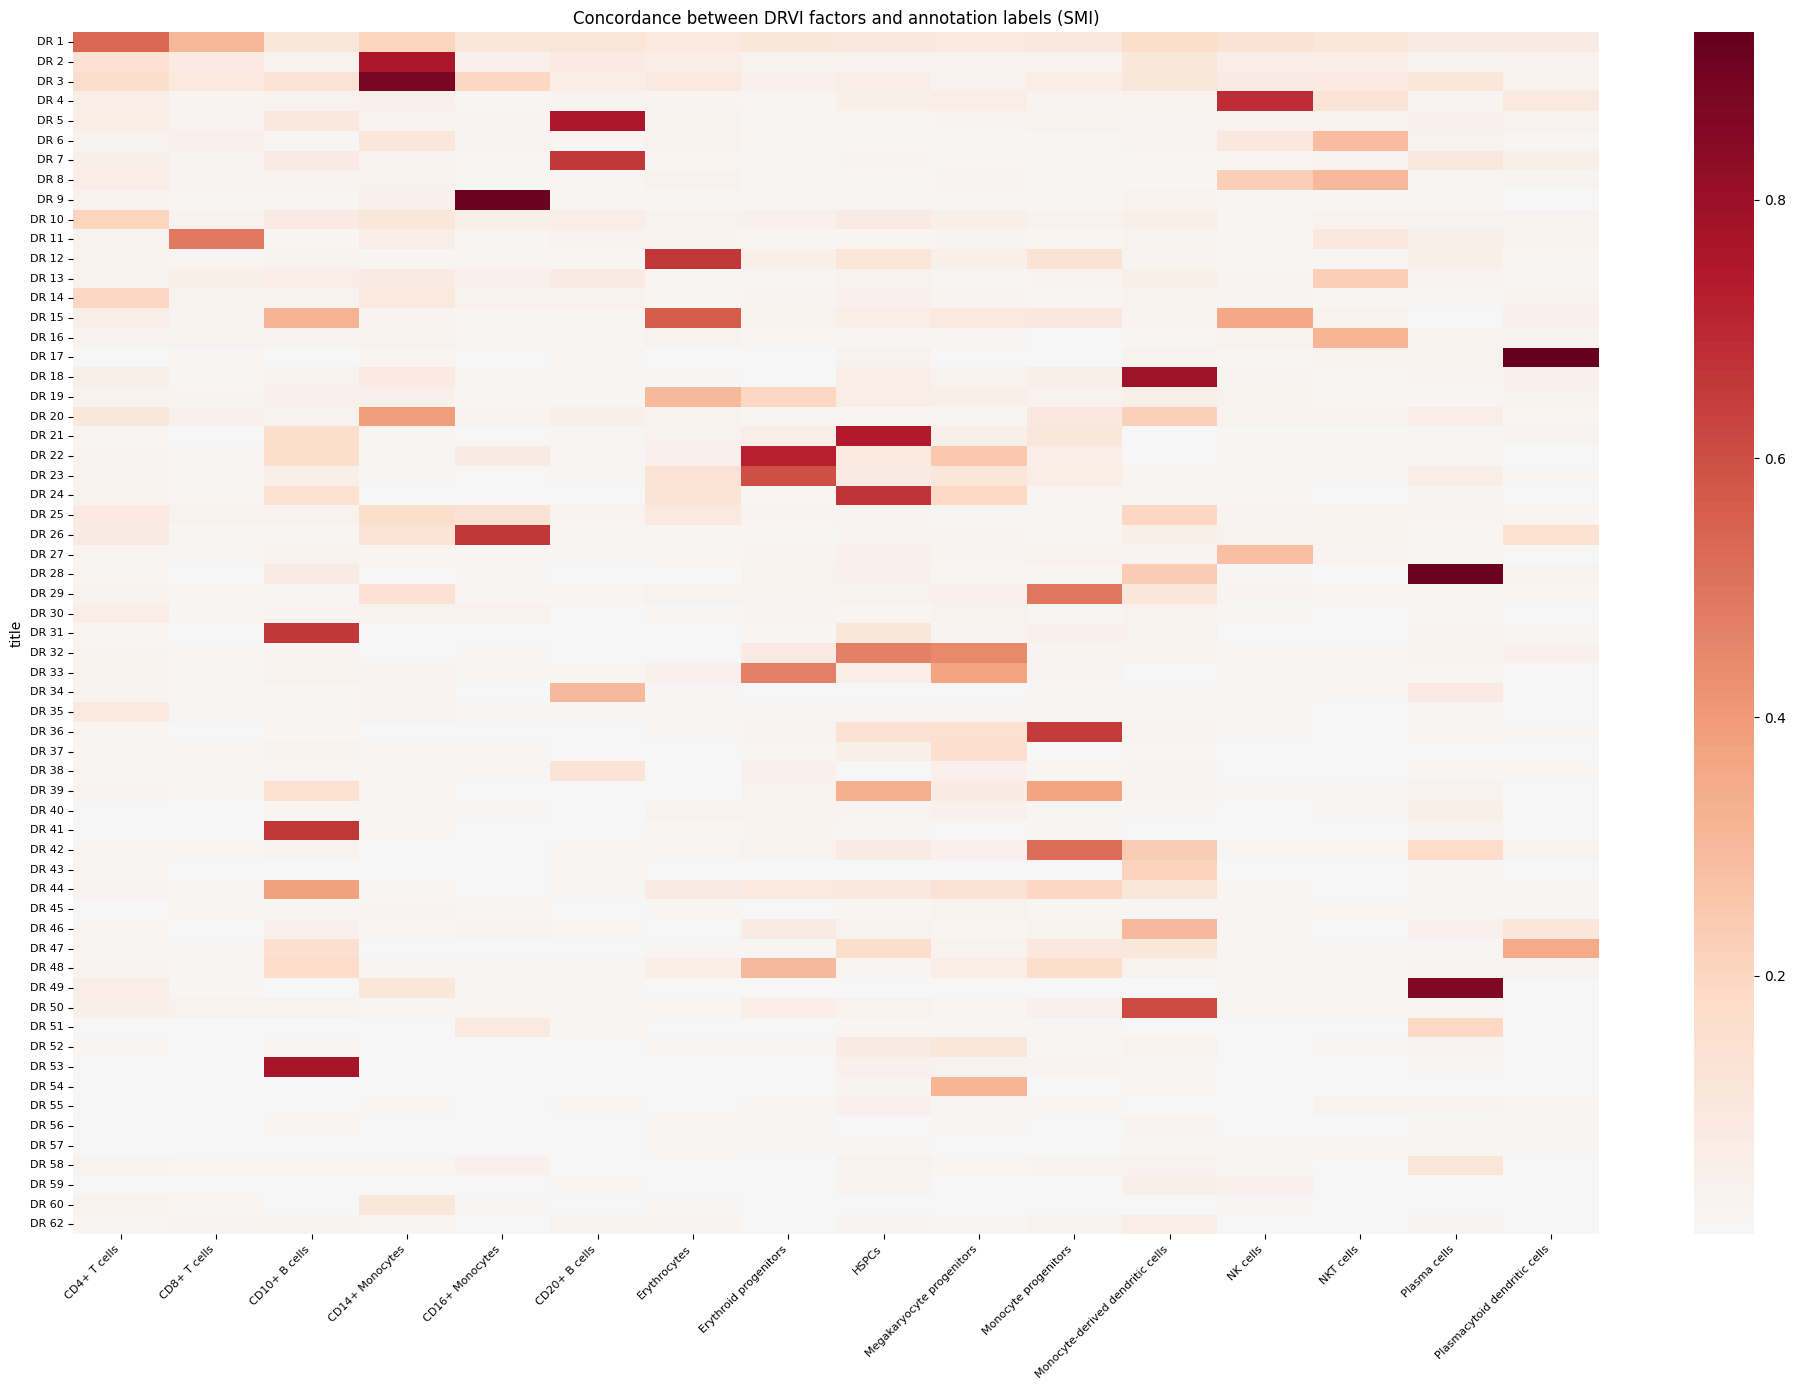

In [38]:
  # Sort factors by numeric index (e.g. "DR 36" → 36) for a readable y-axis ordering.
def _factor_sort_key(name):
    n = str(name).replace("DR", "").strip()
    return int(n) if n.isdigit() else float("inf")

smi_sorted = smi.loc[sorted(smi.index, key=_factor_sort_key)]

plt.figure(figsize=(20, 14))
ax = sns.heatmap(smi_sorted, cmap="RdBu_r", center=0)

ax.set_yticks(np.arange(smi_sorted.shape[0]) + 0.5)
ax.set_yticklabels(smi_sorted.index, rotation=0, fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.title("Concordance between DRVI factors and annotation labels (SMI)")
plt.tight_layout()
plt.show()

#### CellTypist Validation

In [ ]:
factor_to_check = "DR 36"
adata.obs["factor_check"] = drvi_factors[factor_to_check].reindex(adata.obs_names)

UMAP

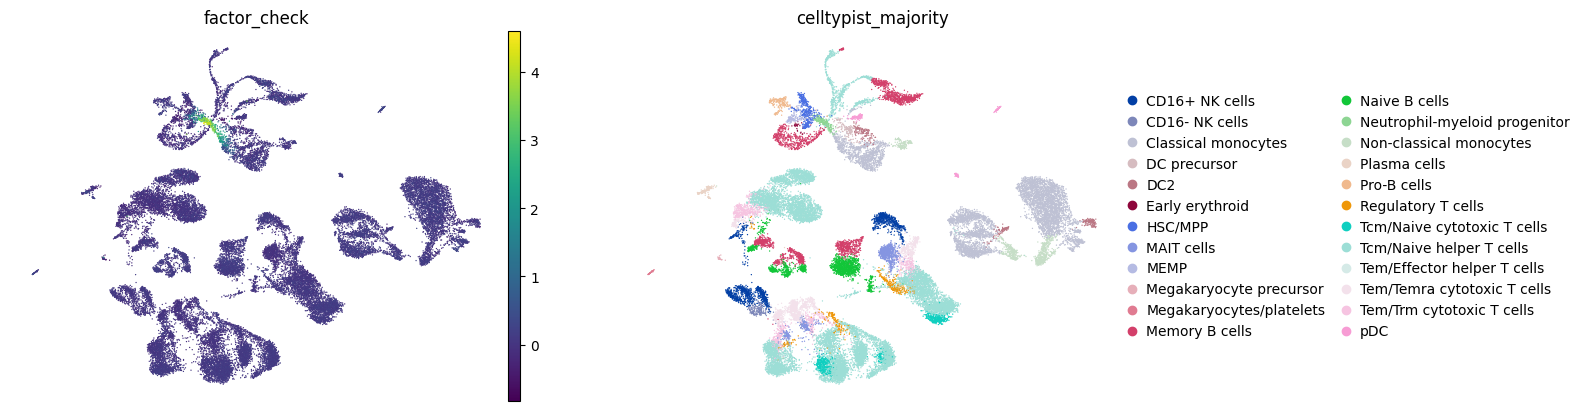

In [40]:
sc.pl.umap(
    adata,
    color=["factor_check", "celltypist_majority"],
    ncols=2,
    frameon=False,
    cmap="viridis",
)


Violin Plot

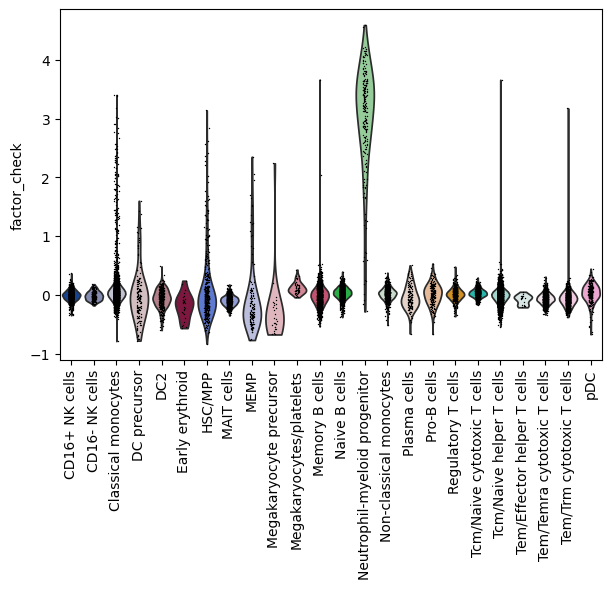

In [41]:
sc.pl.violin(
    adata,
    keys="factor_check",
    groupby="celltypist_majority",
    rotation=90
)

#### CellTypist Summary

In [ ]:
# Low specificity  → factor captures variation shared across multiple types.

# Vectorised: sort each row descending and take the top-2 values at once.
vals      = np.sort(smi.values, axis=1)[:, ::-1]   # shape: (n_factors, n_celltypes)
top_1     = smi.idxmax(axis=1)                       # best cell-type label per factor
top_1_val = pd.Series(vals[:, 0], index=smi.index)  # best SMI score
specificity = pd.Series(vals[:, 0] - vals[:, 1], index=smi.index)  # gap to second-best

celltypist_summary = pd.DataFrame({
    "Factor":       smi.index,
    "Top_CellType": top_1.values,
    "SMI-value":    top_1_val.values,
    "Specificity":  specificity.values,
})
celltypist_summary["Tool"]      = "SMI"
celltypist_summary["Label_std"] = (
    celltypist_summary["Top_CellType"].astype(str)
    .str.lower().str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_")
)
celltypist_summary["Significant"] = (
    (celltypist_summary["SMI-value"]   >= CT_CORR_THRESHOLD)
    & (celltypist_summary["Specificity"] >= CT_SPEC_THRESHOLD)
)

display(celltypist_summary[celltypist_summary["Significant"]])

,Factor,Top_CellType,SMI-value,Specificity,Tool,Label_std,Significant
0,DR 36,Monocyte progenitors,0.652945,0.505441,SMI,monocyte_progenitors,True
1,DR 49,Plasma cells,0.859131,0.744023,SMI,plasma_cells,True
4,DR 2,CD14+ Monocytes,0.761070,0.620771,SMI,cd14_monocytes,True
5,DR 41,CD10+ B cells,0.668039,0.642334,SMI,cd10_b_cells,True
12,DR 29,Monocyte progenitors,0.495314,0.355487,SMI,monocyte_progenitors,True
13,DR 50,Monocyte-derived dendritic cells,0.609541,0.548011,SMI,monocyte_derived_dendritic_cells,True
14,DR 1,CD4+ T cells,0.535119,0.222924,SMI,cd4_t_cells,True
17,DR 5,CD20+ B cells,0.758002,0.660248,SMI,cd20_b_cells,True
23,DR 3,CD14+ Monocytes,0.878655,0.682051,SMI,cd14_monocytes,True
25,DR 11,CD8+ T cells,0.490036,0.388470,SMI,cd8_t_cells,True


### 1.2 GPTCellType

How it works: REQUIRES API KEYS

* Input: Top-ranked marker genes (e.g., top 10–50 genes from DRVI factor loadings) and basic metadata (tissue type and species)
* Reference: 
    * Internal LLM Knowledge: Relies entirely on the pre-trained generative parameters of a single Large Language Model (typically GPT-4 or GPT-4o)
    * Textual Priors: Uses the massive corpus of biomedical literature, textbooks, and database descriptions seen during the model's training phase
* Algorithm: 
    * Direct Prompting: The gene list is formatted into a specialized prompt (e.g., "Assign a cell type or biological process to these genes...")
    * Zero-Shot Heuristics: The model performs a semantic match between the input gene symbols and its internal "memory" of gene functions
    * Single-Pass Logic: Unlike agent-based models, it makes a one-shot decision based on the probability of the next tokens in the sequence
* Output: 
    * Identity Label: A concise name for the cell type or biological program (factor)
    * Brief Rationale: A short text snippet explaining the roles of the key genes that led to the identification
    * Top Marker Alignment: A list showing which input genes most strongly support the assigned label

### 1.3 mLLM CellType

How it works:

* Input: Differentially expressed marker genes (e.g., from FindAllMarkers) and critical metadata like tissue context (e.g., "human brain"), species, and experimental condition
* Reference: 
    * Collective Intelligence: Does not rely on a single database; instead, it synthesizes knowledge from an ensemble of SOTA models (e.g., GPT-5.2, Claude 4.5, Gemini 3 Pro, Qwen3)
    * Zero-Shot Learning: Functions without a pre-existing reference atlas by tapping into the models' internal biomedical training data
* Algorithm: 
    * Initial Annotation: Multiple LLMs independently propose cell type labels and provide biological reasoning for their choice
    * Structured Deliberation: For clusters where models disagree (controversial clusters), the framework initiates a "discussion" phase. Models share their reasoning and cross-evaluate each other's arguments
    * Consensus Checker (CC): A lead model (e.g., Claude 4.5 or GPT-5) acts as a moderator to synthesize the discussion and reach a final consensus
    * Uncertainty Quantification: It calculates the Consensus Proportion (CP) (level of agreement) and Shannon Entropy (H) (diversity of opinions) to flag ambiguous results for human review
* Output: 
    * Consensus Label: The most probable cell type agreed upon by the ensemble
    * Uncertainty Metrics: CP and Shannon Entropy values for every cluster
    * Full Reasoning Log: A transparent record of the debate between models, documenting why specific markers led to the final label

### 1.4 DeepCellSeek

How it works:

* Input: Ranked marker gene lists (top loadings) and specific "Niche" information (e.g., "Human Gut - Inflammatory Bowel Disease")
* Reference: 
    * Multi-LLM Ensemble: Queries a "Council" of the latest models (e.g., GPT-5, Claude 4.1, and Gemini 2 Ultra)
    * Consensus Database: Aggregates knowledge from established ontologies (CL, MeSH) and recent publication pre-prints
* Algorithm: 
    * Systematic Benchmarking: The tool was built by benchmarking 34 datasets to identify the "optimal" prompt engineering for cell annotation
    * Majority Voting: It sends the same gene list to multiple LLMs and uses a weighted voting system to determine the final label
    * Subtype Resolution: It specifically triggers "Deep Dive" prompts when it detects ambiguity between similar cells (e.g., distinguishing different states of Macrophages)
* Output: 
    * Consensus Label: The final agreed-upon cell type name
    * Ensemble Agreement Score: A percentage showing how many of the internal models agreed on the label
    * Evidence Summary: A concise list of literature-backed reasons why specific markers (from your DRVI list) point to the chosen label

### 1.5 CellAgent

How it works: REQUIRES API KEYS

* Input: High-confidence marker gene lists (e.g., top genes from DRVI factor loadings) and study metadata (e.g., tissue type, species)
* Reference: 
    * External Knowledge Integration: Actively queries curated databases like CellMarker, PanglaoDB, and Azimuth
    * Internal LLM Corpus: Leverages the vast biological literature embedded in Large Language Models (typically GPT-4 or GPT-5)
* Algorithm: multi agent orchestration
    * The Planner: Formulates a search strategy based on the input context
    * The Executor: Retrieves evidence from databases and matches input genes against known cell-type signatures
    * The Evaluator: Critically reviews the proposed labels for biological plausibility and cross-references them with the original data
    --> Iterative Reasoning: If the Evaluator detects a mismatch (e.g., a "Muscle cell" label for a "Brain" sample), the agents enter a feedback loop to refine the search and resolve conflicts
* Output: 
    * Predicted Cell Type: The final consensus label for the cell cluster or factor
    * Confidence Score: A metric indicating the certainty of the multi-agent agreement
    * Reasoning Trace: A step-by-step logical justification (narrative) explaining the biological evidence used for the decision
    * Marker Validation: A list of specific input genes that were successfully validated against the reference databases

## 2. Annotation of Biological Processes (Funtional Identity)

Goal: Identify biological processes (e.g., "Interferon Response", "Cell Cycle") for factors that do not map 1-to-1 to a cell type.

Tools to Compare:

* Gene Set Enrichment Analysis:
    * gProfiler (gprofiler-official): The benchmark used in the DRVI preprint
    * Gseapy: Python implementation for local Enrichment analysis (Enrichr/MSigDB)
    * Decoupler: A fast framework for footprint-based enrichment (e.g., PROXIMA)
    * Blitzqseq
* LLM-based tools:
    * Requires API keys:
        * AnnDictionary: It provides a structured metadata framework within AnnData objects to map latent representations and gene sets to standardized biological vocabularies using LLM-backed dictionaries
        *  Cell Agent: It employs a multi-agent "Plan-and-Execute" hierarchy where specialized AI agents collaborate to perform data tool manipulation, literature retrieval, and iterative biological reasoning
    * Does NOT require API keys or can use local open-source resources:
        * EnrichGT: It bridges classical statistics and semantics by taking raw ORA/GSEA results and using LLMs to perform intelligent clustering and context-aware summarization of biological pathways
        * Cell2Text-V2: It transforms numerical gene expression matrices and factor loadings into coherent natural language descriptions by leveraging refined prompt engineering and retrieval-augmented domain knowledge



Key Metrics:

### 2.1 Blitzqseq

How it works:
* Input: Ranked gene list (list of ALL genes sorted by loadings for a specific factor)
* Reference: Database on Enrichr
    * Key Collections: 
        * e.g MgSigDB
            * H (Hallmark): Broad biological states (e.g., "Hypoxia", "Inflammatory Response").
            * C5 (GO): Highly specific Gene Ontology terms.
            * C2 (CP): Curated pathways from Reactome or KEGG.
        * Cellmarker/Azimuth
        * Reactome/KEGG
* Algorithm: 
    * Pre-ranking: Unlike standard GSEA which compares groups of cells, this version only looks at the ranking of genes
    * It calculates an Enrichment Score (ES) that increases when genes from a specific pathway appear at the top of your ranked list (high loadings)
    * Speed Optimization: BlitzGSEA uses a probability distribution approximation to estimate the null model. Instead of running thousands of slow permutations for every gene set, it uses mathematical shortcuts to calculate p-values almost instantly
* Output: 
    * NES (Normalized Enrichment Score): A high positive NES indicates that the biological process is strongly represented by that factor
    * p-value & FDR (q-value): Statistical significance. Usually, you filter for FDR<0.05
    * Leading Edge Genes: The specific subset of genes within a pathway that actually drove the enrichment score

#### BlitzGSEA Library

In [43]:
signature_lib = blitz.enrichr.get_library(GSEA_DB)
print(f"Loaded blitzgsea library '{GSEA_DB}': {len(signature_lib)} gene sets")

Loaded blitzgsea library 'Azimuth_Cell_Types_2021': 341 gene sets


##### BlitzGSEA

In [44]:
# BlitzGSEA: fast analytic GSEA approximation.
# Input:  ranked gene list per factor (all genes sorted by descending effect score).
# Method: Approximates the running-sum statistic of classic GSEA using an analytic null distribution, avoiding permutation tests for faster execution.
# Output per gene set: NES (Normalized Enrichment Score), FDR (False Discovery Rate).
blitz_rows = []

for factor_dir, s in ranked_inputs.items():
    sig = s.dropna().reset_index()
    sig.columns = ["i", "v"]  # blitzgsea requires 2-column format: gene, score

    try:
        res = blitz.gsea(sig, signature_lib, processes=BLITZGSEA_PROCESSES)
        if res is None or res.empty:
            continue

        term = res["Term"] if "Term" in res.columns else pd.Series(res.index, index=res.index)
        fdr = res["fdr"] if "fdr" in res.columns else res["FDR"]
        nes = res["nes"] if "nes" in res.columns else res["NES"]

        blitz_rows.append(pd.DataFrame({
            "FactorDir": factor_dir,
            "Term": term.astype(str).values,
            "NES": pd.to_numeric(nes, errors="coerce").values,
            "FDR": pd.to_numeric(fdr, errors="coerce").values
        }))
    except Exception:
        pass

blitzgsea_summary = pd.concat(blitz_rows, ignore_index=True) if blitz_rows else pd.DataFrame(columns=["FactorDir", "Term", "NES", "FDR"])



In [45]:
sig_blitz = blitzgsea_summary.query("FDR < @FDR")[["FactorDir", "Term", "NES", "FDR"]].copy()
sig_blitz["Factor"] = strip_factor(sig_blitz["FactorDir"]).values
sig_blitz = _enrich_sig(sig_blitz, blitzgsea_summary, "FactorDir", "NES", use_nes=True)
display(sig_blitz.sort_values("FDR"))

,FactorDir,Term,NES,FDR,Factor,Annot_Label,Annot_SMI,Specificity
67,DR 4_pos,Myeloid Dendritic Type 2 CL0000782,-4.902211,0.000101,DR 4,NK cells,0.686,0.621403
55,DR 7_pos,CD16+ Monocyte CL0002396,-4.698796,0.000280,DR 7,CD20+ B cells,0.654,1.514947
6,DR 2_neg,Dendritic Cell CL0000451,-4.609045,0.000433,DR 2,CD14+ Monocytes,0.761,0.870776
85,DR 44_neg,Dendritic Cell CL0000451,-4.594900,0.000463,DR 44,CD10+ B cells,0.382,0.682361
10,DR 29_pos,Dendritic Cell CL0000451,-4.548259,0.000579,DR 29,Monocyte progenitors,0.495,0.768737
...,...,...,...,...,...,...,...,...
91,DR 27_neg,Dendritic Cell CL0000451,-3.350363,0.043178,DR 27,NK cells,0.279,0.103669
90,DR 27_neg,Myeloid Dendritic Type 2 CL0000782,-3.454032,0.043178,DR 27,NK cells,0.279,0.103669
22,DR 20_neg,Conventional Dendritic Cell 2 2 CL0002399,-3.151542,0.043445,DR 20,CD14+ Monocytes,0.392,0.539322
35,DR 19_pos,Conventional Dendritic Cell 2 2 CL0002399,-3.202524,0.048588,DR 19,Erythrocytes,0.302,0.477704


#### BlitzGSEA Summary

In [46]:
annotated_blitz = blitzgsea_summary[blitzgsea_summary["FDR"] < FDR].copy() if not blitzgsea_summary.empty else pd.DataFrame()
tool_coverage_summary(blitzgsea_summary, annotated_blitz, "FactorDir", "Term", "FDR", "BlitzGSEA", effect_type="nes")

BlitzGSEA coverage (FDR<0.05): 66.67% (40/60)
Unique terms: 8
Median NES: -3.91


### 2.2 Gseapy (Preranking Module)

How it works:
* Input: 
    * Ranked gene list (list of ALL genes sorted by loadings for a specific factor) for Preranked Module [Important: Gene names have to be in capital letters]
    * Gene expression matrix and group annotation for classical module
* Reference: Database on Enrichr
    * Key Collections: 
        * e.g MgSigDB
            * H (Hallmark): Broad biological states (e.g., "Hypoxia", "Inflammatory Response").
            * C5 (GO): Highly specific Gene Ontology terms.
            * C2 (CP): Curated pathways from Reactome or KEGG.
        * Cellmarker/Azimuth
        * Reactome/KEGG
* Algorithm: 
    * Pre-ranking: Unlike standard GSEA which compares groups of cells, this version only looks at the ranking of genes
    * It calculates an Enrichment Score (ES) that increases when genes from a specific pathway appear at the top of your ranked list (high loadings)
    * Permutation-based Null Model: It randomly reassigns gene labels many times (default is 1000 iterations) to see how often a similar ES occurs by pure chance
* Output: 
    * NES (Normalized Enrichment Score): A high positive NES indicates that the biological process is strongly represented by that factor
    * FDR (q-value): Statistical significance. Usually, you filter for FDR<0.05
    * Lead_genes: The specific subset of genes within a pathway that actually drove the enrichment score

#### Get Gene Library

In [47]:
gseapy_lib = gseapy.get_library(GSEA_DB)
print(f"gseapy DB: {GSEA_DB} | gene sets: {len(gseapy_lib)}")

gseapy DB: Azimuth_Cell_Types_2021 | gene sets: 341


#### Run Gseapy Prerank Loop


In [48]:
# GSEApy Prerank: permutation-based GSEA.
# Input:  ranked gene list per factor (same as BlitzGSEA).
# Method: Classic running-sum statistic with permutation-based null model.
# Output per gene set: NES (Normalized Enrichment Score), FDR (q-value).
rng = np.random.default_rng(seed=42)
gseapy_rows = []

for factor_dir, s in ranked_inputs.items():
    rnk = s.reset_index()
    rnk.columns = ["gene", "score"]
    rnk["score"] = rnk["score"] + rng.normal(0, 1e-8, size=len(rnk))  # break ties
    if rnk["score"].dropna().nunique() < 2:
        continue
    try:
        pre_res = gseapy.prerank(
            rnk=rnk,
            gene_sets=gseapy_lib,
            min_size=GSEAPY_MIN_SIZE,
            max_size=GSEAPY_MAX_SIZE,
            permutation_num=GSEAPY_PERMUTATIONS,
            outdir=None,
            seed=0,
            verbose=False,
        )
        res = pre_res.res2d
        if res is None or res.empty:
            continue
        term_col = _pick_col(res, ["Term", "term"])
        nes_col  = _pick_col(res, ["NES", "nes"])
        fdr_col  = _pick_col(res, ["FDR q-val", "FDR", "fdr"])
        if term_col is None or nes_col is None or fdr_col is None:
            continue
        gseapy_rows.append(pd.DataFrame({
            "FactorDir": factor_dir,
            "Term": res[term_col].astype(str).values,
            "NES": pd.to_numeric(res[nes_col], errors="coerce").values,
            "FDR": pd.to_numeric(res[fdr_col], errors="coerce").values,
        }))
    except Exception:
        continue

gseapy_summary = pd.concat(gseapy_rows, ignore_index=True) if gseapy_rows else pd.DataFrame(columns=["FactorDir", "Term", "NES", "FDR"])


In [49]:
sig_gseapy = gseapy_summary.query("FDR < @FDR")[["FactorDir", "Term", "NES", "FDR"]].copy()
sig_gseapy["Factor"] = strip_factor(sig_gseapy["FactorDir"]).values
sig_gseapy = _enrich_sig(sig_gseapy, gseapy_summary, "FactorDir", "NES", use_nes=True)
display(sig_gseapy.sort_values("FDR"))

,FactorDir,Term,NES,FDR,Factor,Annot_Label,Annot_SMI,Specificity
0,DR 33_neg,Platelet/Megakaryocyte CL0000763,1.191702,0.004032,DR 33,Erythroid progenitors,0.469,0.021365
8,DR 48_neg,Platelet/Megakaryocyte CL0000763,-1.948028,0.006242,DR 48,Erythroid progenitors,0.299,0.193533
7,DR 60_neg,CD4+ Cytotoxic T CL0000934,-2.085919,0.007964,DR 60,CD14+ Monocytes,0.102,0.252451
9,DR 4_neg,CD8+ Effector Memory T 4 CL0001050,-1.913863,0.016952,DR 4,NK cells,0.686,0.328998
4,DR 25_pos,Plasmacytoid Dendritic CL0000784,1.936606,0.019081,DR 25,Monocyte-derived dendritic cells,0.197,0.188042
12,DR 34_neg,Dendritic Cell CL0000451,1.907370,0.019119,DR 34,CD20+ B cells,0.300,0.310167
6,DR 19_neg,CD4+ Naive T CL0000895,-1.879251,0.022394,DR 19,Erythrocytes,0.302,0.274196
2,DR 57_pos,Nonclassical Monocyte CL0000875,1.254732,0.026892,DR 57,Plasma cells,0.020,0.051115
11,DR 31_pos,Platelet/Megakaryocyte CL0000763,1.851756,0.035197,DR 31,CD10+ B cells,0.659,0.104820
5,DR 40_neg,CD4+ Naive T CL0000895,-1.857469,0.035477,DR 40,Plasma cells,0.054,0.194538


#### Gseapy Summary


In [50]:
annotated_gseapy = gseapy_summary[gseapy_summary["FDR"] < FDR].copy() if not gseapy_summary.empty else pd.DataFrame()
tool_coverage_summary(gseapy_summary, annotated_gseapy, "FactorDir", "Term", "FDR", "GSEApy", effect_type="nes")


GSEApy coverage (FDR<0.05): 21.31% (13/61)
Unique terms: 10
Median NES: -1.83


### 2.3 gprofiler

How it works:
* Input: 
    * Ordered gene list: List of genes sorted by loadings (only top list as query)
    * Background Gene Set: List of all genes that were measured in experiment
    * Identifiers: many formats can be converted by g:Convert
* Reference: broad integration of many sources (g:GOSt)
    * Gene Ontology
    * Biological Pathways: KEGG, Reactome,..
    * Regulatory Motifs: Transfaci, MIRNA
    * Protein data bases
    * ...
* Algorithm: Over Representation Analysis
    * Hypergeometric test: calculates probability that overlap is only by pure chance
    * Ordered Query: It calculates a p-value at each step and identifies the specific "cutoff" point where the enrichment significance is at its maximum (the lowest p-value)
    * g:SCS (Significance Threshold): own algorithm to correct for multiple testing, optimized for hierarchical structure of GO-terms (tighter than FDR)
* Output: 
    * p-value
    * Intersection size: how many of your genes are found in pathway
    * Manhattan plot: interactive visualization that groups results by data base

In [51]:
gp = GProfiler(return_dataframe=True)

#### gprofiler Helper function

In [52]:
# Over-Representation Analysis (ORA) / ordered-query via g:Profiler.
# When GP_ORDERED=True the full sorted gene list is passed; g:Profiler finds the
# optimal cutoff automatically (more sensitive than a fixed TOP_N cut).
# When GP_ORDERED=False the top-N list is used (classic ORA).
# Method: Hypergeometric test with g:SCS multiple-testing correction.
# Output: DataFrame with columns including 'p_value', 'name', 'source', 'factor'.
def run_gprofiler_for_gene_list(genes, factor, direction):
    genes = pd.Series(genes).dropna().astype(str).drop_duplicates().tolist()
    if not genes:
        return pd.DataFrame()

    kwargs = dict(
        organism=GP_ORGANISM,
        query=genes,
        user_threshold=GP_USER_THRESHOLD,
        ordered=GP_ORDERED,
        background=ALL_GENES,
    )
    if GP_SOURCES:
        kwargs["sources"] = GP_SOURCES

    res = gp.profile(**kwargs)
    if res is None or res.empty:
        return pd.DataFrame()

    res = res.copy()
    res["factor"] = factor
    res["direction"] = direction
    return res


#### Run gprofiler

In [53]:
gprofiler_parts = []
for fac in factor_ids:
    # When GP_ORDERED=True pass the full sorted gene list so g:Profiler can find
    # the optimal enrichment cutoff; otherwise use the fixed top-N list.
    pos_genes = pos_ranked[fac].index.tolist() if GP_ORDERED else pos_top[fac]
    neg_genes = neg_ranked[fac].index.tolist() if GP_ORDERED else neg_top[fac]
    gprofiler_parts.append(run_gprofiler_for_gene_list(pos_genes, fac, "pos"))
    gprofiler_parts.append(run_gprofiler_for_gene_list(neg_genes, fac, "neg"))

gprofiler_valid = [x for x in gprofiler_parts if not x.empty]
gprofiler_res = pd.concat(gprofiler_valid, ignore_index=True) if gprofiler_valid else pd.DataFrame()

AssertionError: query failed with error 504

#### gProfiler Results

In [ ]:
sig_gprof = gprofiler_res.query("p_value < @FDR").copy()
sig_gprof["Term"] = sig_gprof["name"] if "name" in sig_gprof else sig_gprof["native"]
sig_gprof = sig_gprof.rename(columns={"factor": "Factor"})
sig_gprof = _enrich_sig(
    sig_gprof,
    gprofiler_res.rename(columns={"factor": "Factor"}),
    "Factor", "p_value",
)
display(sig_gprof[["Factor", "Term", "p_value", "Specificity", "Annot_Label", "Annot_SMI"]]
        .sort_values("p_value").head(20))


,Factor,Term,p_value,Specificity,Annot_Label,Annot_SMI
56289,DR 4,cell activation,4.615666e-55,1.429910,NK cells,0.686
81364,DR 43,cell activation,1.847839e-54,0.945761,Monocyte-derived dendritic cells,0.215
69083,DR 21,cell activation,1.847839e-54,1.052569,HSPCs,0.737
28795,DR 58,cell activation,1.847839e-54,0.676297,Plasma cells,0.121
68342,DR 18,cell activation,1.847839e-54,1.052569,Monocyte-derived dendritic cells,0.791
77625,DR 17,cell activation,1.847839e-54,1.138609,Plasmacytoid dendritic cells,0.929
14445,DR 47,cell activation,1.847839e-54,0.103897,Plasmacytoid dendritic cells,0.350
74060,DR 28,cell activation,1.847839e-54,0.181506,Plasma cells,0.914
10785,DR 59,cell activation,1.847839e-54,0.481744,Monocyte-derived dendritic cells,0.051
25872,DR 39,cell activation,1.847839e-54,0.546655,Monocyte progenitors,0.375


#### gprofiler Summary

In [ ]:
g_sig = gprofiler_res[gprofiler_res["p_value"] < FDR].copy() if not gprofiler_res.empty else pd.DataFrame()
g_terms_col = "name" if "name" in g_sig.columns else "native"
tool_coverage_summary(gprofiler_res, g_sig, "factor", g_terms_col, "p_value", "g:Profiler")




g:Profiler coverage (FDR<0.05): 100.00% (61/61)
Unique terms: 2156
Median -log10(p): 3.93


### 2.4 Decoupler

How it works:
* Input: 
    * Matrix: expects gene sets in long format (source, target, weight)
* Reference: Omnipath which is a metadata base that integrates many different data bases
    * enables access too almost every available data abse using dc.get_resource()
* Algorithm: Ensemble platform --> run different methods on same data set
    * Multivariate Linear Model: very fast and often more precise than GSEA for loadings
    * Univariate Linear Model: similar to statistical regression
    * AUCell: measure activity of gene sets in individual cells/factors\
    * ORA & GSEA
* Output: Activity Scores --> how active a process is in a factor
    * Concencus Score --> can combine different methods for more robust results

#### Load gene set

In [54]:
net_dispatch = {
    "hallmark":  lambda: dc.op.hallmark(organism=DC_ORGANISM),
    "progeny":   lambda: dc.op.progeny(organism=DC_ORGANISM),
    "dorothea":  lambda: dc.op.dorothea(organism=DC_ORGANISM, levels=["A", "B", "C"]),
    "collectri": lambda: dc.op.collectri(organism=DC_ORGANISM),
}
net = net_dispatch.get(DC_GENESET.strip().lower(),
                        lambda: dc.op.resource(name=DC_GENESET, organism=DC_ORGANISM))()

cols = ["source", "target"] + (["weight"] if "weight" in net.columns else [])
net = net[cols].dropna().drop_duplicates().reset_index(drop=True)
print(f"Network loaded: {len(net)} interactions, {net['source'].nunique()} gene sets")

Network loaded: 62421 interactions, 14 gene sets


#### Runner Decoupler

In [55]:
# Footprint-based enrichment via decoupler.
# Input:  factors x genes score matrix (transposed from build_inputs output).
# Methods: ULM, MLM, z-score (configurable via DC_METHODS).
# Stouffer consensus p-values are computed across methods.
# Output: long-format DataFrame with columns [factor, term, p_value, direction].
def run_decouple(df_factors_by_genes: pd.DataFrame, direction: str) -> pd.DataFrame:
    mat = df_factors_by_genes.copy()
    mat.columns = mat.columns.astype(str).str.strip().str.upper()
    mat = mat.reindex(columns=ALL_GENES, fill_value=0.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    net_use = net.copy()
    net_use["target"] = net_use["target"].astype(str).str.strip().str.upper()

    res = dc.mt.decouple(
        data=mat,
        net=net_use,
        methods=DC_METHODS,
        cons=False,
        tmin=DC_TMIN,
        verbose=False,
    )
    _, pvals = dc.mt.consensus(res)

    out = pvals.stack().rename("p_value").reset_index()
    out.columns = ["factor", "term", "p_value"]
    # BH correction so FDR < 0.05 is comparable with other tools
    _, p_adj, _, _ = multipletests(out["p_value"].values, method="fdr_bh")
    out["p_value"] = p_adj
    out["direction"] = direction
    return out

#### Run Decoupler

In [56]:
dec_pos = run_decouple(pos_std.T, "pos")
dec_neg = run_decouple(neg_std.T, "neg")
decoupler_res = pd.concat([dec_pos, dec_neg], ignore_index=True)

print("rows:", len(decoupler_res))
print("unique factors:", strip_factor(decoupler_res["factor"]).nunique())
print("unique terms:", decoupler_res["term"].nunique())
print("significant rows:", (decoupler_res["p_value"] < FDR).sum())

rows: 924
unique factors: 60
unique terms: 14
significant rows: 0


#### Results Decoupler

In [57]:
sig_dec = decoupler_res.query("p_value < @FDR")[["factor", "term", "p_value"]].copy()
sig_dec = sig_dec.rename(columns={"factor": "Factor"})
spec = compute_tool_specificity(decoupler_res.rename(columns={"factor": "Factor"}), "Factor", "p_value")
sig_dec = sig_dec.merge(annot_map, on="Factor", how="left").merge(spec, left_on="Factor", right_index=True, how="left")
display(sig_dec.sort_values("p_value"))

,Factor,term,p_value,Annot_Label,Annot_SMI,Specificity


#### Decoupler Summary

In [58]:
d_sig = decoupler_res[decoupler_res["p_value"] < FDR].copy() if not decoupler_res.empty else pd.DataFrame()
tool_coverage_summary(decoupler_res, d_sig, "factor", "term", "p_value", "decoupler")

decoupler coverage (FDR<0.05): 0.00% (0/60)
Unique terms: 0
Median -log10(p): nan


## 3. Multi-Database Benchmark Loop
Runs every (tool, database) combination defined in `LIBRARIES`.
Results are collected into `all_results` (standardized schema) and split into
`all_results_celltype` / `all_results_bioproc` for downstream comparison.
Each run is cached independently — re-running the cell only recomputes missing combinations.

### Per-tool runner functions

In [59]:
# ---------------------------------------------------------------------------
# Per-tool runner functions — each accepts db_name and returns a raw DataFrame
# in that tool's native format. standardize_results() converts to shared schema.
# ---------------------------------------------------------------------------

#uses ranked_inputs returns standardized columns
def run_blitzgsea_db(db_name, min_size=10, max_size=500):
    lib = blitz.enrichr.get_library(db_name)
    rows = []
    rng = np.random.default_rng(seed=42)
    for factor_dir, s in ranked_inputs.items():
        sig = s.dropna().reset_index()
        sig.columns = ["i", "v"]
        # Sanitize non-finite scores so blitzgsea's solver does not see inf
        v = sig["v"].astype(float)
        v = v.replace([np.inf, -np.inf], np.nan)
        vmax, vmin = v.max(), v.min()
        v = v.fillna(vmax if np.isfinite(vmax) else 1e10).replace(-np.inf, vmin if np.isfinite(vmin) else -1e10)
        sig["v"] = v
        # Jitter to break ties / avoid zero variance (same idea as gseapy)
        sig["v"] = sig["v"] + rng.normal(0, 1e-8, size=len(sig))
        if sig["v"].nunique() < 2:
            continue
        try:
            res = blitz.gsea(sig, lib, processes=BLITZGSEA_PROCESSES)
            if res is None or res.empty:
                continue
            term = res["Term"] if "Term" in res.columns else pd.Series(res.index, index=res.index)
            fdr  = res["fdr"]  if "fdr"  in res.columns else res["FDR"]
            nes  = res["nes"]  if "nes"  in res.columns else res["NES"]
            rows.append(pd.DataFrame({
                "FactorDir": factor_dir,
                "Term": term.astype(str).values,
                "NES":  pd.to_numeric(nes, errors="coerce").values,
                "FDR":  pd.to_numeric(fdr, errors="coerce").values,
            }))
        except Exception as e:
            logging.warning("run_blitzgsea_db failed for %s: %s", factor_dir, e)
            continue
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["FactorDir", "Term", "NES", "FDR"])


def run_gseapy_db(db_name, min_size=10, max_size=500):
    try:
        lib = gseapy.get_library(db_name)
    except Exception as e:
        # Enrichr API often unreachable on clusters; use blitzgsea's library (same Enrichr content)
        logging.warning("gseapy.get_library(%s) failed (%s); using blitzgsea enrichr fallback.", db_name, e)
        lib = blitz.enrichr.get_library(db_name)
    rng = np.random.default_rng(seed=42)
    rows = []
    for factor_dir, s in ranked_inputs.items():
        rnk = s.reset_index()
        rnk.columns = ["gene", "score"]
        rnk["score"] = rnk["score"] + rng.normal(0, 1e-8, size=len(rnk))
        if rnk["score"].dropna().nunique() < 2:
            continue
        try:
            pre_res = gseapy.prerank(
                rnk=rnk, gene_sets=lib,
                min_size=min_size, max_size=max_size,
                permutation_num=GSEAPY_PERMUTATIONS,
                outdir=None, seed=0, verbose=False,
            )
            res = pre_res.res2d
            if res is None or res.empty:
                continue
            term_col = _pick_col(res, ["Term", "term"])
            nes_col  = _pick_col(res, ["NES", "nes"])
            fdr_col  = _pick_col(res, ["FDR q-val", "FDR", "fdr"])
            if None in (term_col, nes_col, fdr_col):
                continue
            rows.append(pd.DataFrame({
                "FactorDir": factor_dir,
                "Term": res[term_col].astype(str).values,
                "NES":  pd.to_numeric(res[nes_col], errors="coerce").values,
                "FDR":  pd.to_numeric(res[fdr_col], errors="coerce").values,
            }))
        except Exception as e:
            logging.warning("run_gseapy_db failed for %s: %s", factor_dir, e)
            continue
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["FactorDir", "Term", "NES", "FDR"])


#uses 'sources=db_name', full ranked list when GP_ORDERED=True, top-N list otherwise; batch API (one call per db)
def run_gprofiler_db(db_name):
    """db_name is a gprofiler source string e.g. 'GO:BP', 'REAC', 'KEGG'. Uses batch query (one API call per db)."""
    queries = {}
    for fac in factor_ids:
        pos_genes = pos_ranked[fac].index.tolist() if GP_ORDERED else pos_top[fac]
        neg_genes = neg_ranked[fac].index.tolist() if GP_ORDERED else neg_top[fac]
        for key_suffix, genes in [("pos", pos_genes), ("neg", neg_genes)]:
            genes = pd.Series(genes).dropna().astype(str).drop_duplicates().tolist()
            if genes:
                queries[f"{fac}_{key_suffix}"] = genes
    if not queries:
        return pd.DataFrame()
    try:
        res = gp.profile(
            organism=GP_ORGANISM, query=queries,
            user_threshold=GP_USER_THRESHOLD,
            ordered=GP_ORDERED, background=ALL_GENES,
            sources=[db_name],
        )
        if res is None or res.empty:
            return pd.DataFrame()
        res = res.copy()
        if "query" not in res.columns:
            return pd.DataFrame()
        # Parse query key (e.g. "DR 1_pos") -> factor, direction
        parts = res["query"].astype(str).str.rsplit("_", n=1, expand=True)
        res["factor"]    = parts[0].values
        res["direction"] = parts[1].values
        return res
    except Exception as e:
        logging.warning("run_gprofiler_db failed for %s: %s", db_name, e)
        return pd.DataFrame()


def run_decoupler_db(db_name):
    """db_name is a decoupler canonical name e.g. 'hallmark', 'progeny', 'collectri'."""
    net_dispatch = {
        "hallmark":  lambda: dc.op.hallmark(organism=DC_ORGANISM),
        "progeny":   lambda: dc.op.progeny(organism=DC_ORGANISM),
        "dorothea":  lambda: dc.op.dorothea(organism=DC_ORGANISM, levels=["A", "B", "C"]),
        "collectri": lambda: dc.op.collectri(organism=DC_ORGANISM),
    }
    net_db = net_dispatch.get(db_name.strip().lower(),
                              lambda: dc.op.resource(name=db_name, organism=DC_ORGANISM))()
    # #region agent log
    import json
    import os
    _log_path = os.path.join(os.path.abspath(os.curdir), ".cursor", "debug-404327.log")
    os.makedirs(os.path.dirname(_log_path), exist_ok=True)
    with open(_log_path, "a") as _f:
        _f.write(json.dumps({"sessionId": "404327", "runId": "run1", "hypothesisId": "H1", "location": "run_decoupler_db", "message": "net_db columns", "data": {"db_name": db_name, "columns": list(net_db.columns) if net_db is not None else None, "shape": net_db.shape if net_db is not None else None}, "timestamp": int(__import__("time").time() * 1000)}) + "\n")
    # #endregion
    # Normalize columns: some resources (e.g. PanglaoDB via dc.op.resource) use different names
    _src = "source" if "source" in net_db.columns else next((c for c in ["geneset", "pathway", "cell_type", "set", "category", "entity"] if c in net_db.columns), None)
    _tgt = "target" if "target" in net_db.columns else next((c for c in ["gene", "gene_symbol", "protein"] if c in net_db.columns), None)
    if _src is None or _tgt is None:
        logging.warning("run_decoupler_db: %s has no source/target-like columns (got %s); skipping.", db_name, list(net_db.columns))
        return pd.DataFrame()
    if _src != "source" or _tgt != "target":
        net_db = net_db.rename(columns={_src: "source", _tgt: "target"})
    cols = ["source", "target"] + (["weight"] if "weight" in net_db.columns else [])
    net_db = net_db[cols].dropna().drop_duplicates().reset_index(drop=True)

    def _run_one(df_t, direction):
        mat = df_t.copy()
        mat.columns = mat.columns.astype(str).str.strip().str.upper()
        mat = mat.reindex(columns=ALL_GENES, fill_value=0.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        net_use = net_db.copy()
        net_use["target"] = net_use["target"].astype(str).str.strip().str.upper()
        res = dc.mt.decouple(data=mat, net=net_use, methods=DC_METHODS, cons=False, tmin=DC_TMIN, verbose=False)
        _, pvals = dc.mt.consensus(res)
        out = pvals.stack().rename("p_value").reset_index()
        out.columns = ["factor", "term", "p_value"]
        # BH correction so FDR < 0.05 is comparable with other tools
        _, p_adj, _, _ = multipletests(out["p_value"].values, method="fdr_bh")
        out["p_value"] = p_adj
        out["direction"] = direction
        return out

    return pd.concat([_run_one(pos_std.T, "pos"), _run_one(neg_std.T, "neg")], ignore_index=True)

### Benchmark loop

In [60]:
# ---------------------------------------------------------------------------
# Benchmark loop — iterates over LIBRARIES and runs each (tool, database) pair.
# Results are cached per combination; set overwrite=True in the config cell
# to force re-computation.
# ---------------------------------------------------------------------------
TOOL_RUNNERS = {
    "blitzgsea": lambda db, cfg: run_blitzgsea_db(db, cfg.get("min_size", 10), cfg.get("max_size", 500)),
    "gseapy":    lambda db, cfg: run_gseapy_db(db, cfg.get("min_size", 10), cfg.get("max_size", 500)),
    "gprofiler": lambda db, cfg: run_gprofiler_db(db),
    "decoupler": lambda db, cfg: run_decoupler_db(db),
}

all_results = []

for lib_cfg in LIBRARIES:
    canonical_db = lib_cfg["db_name"]
    tool         = lib_cfg["tool"]
    domain       = lib_cfg["domain"]

    # Resolve tool-specific database name; skip if None (unsupported combination)
    tool_db = DB_NAME_MAP.get(canonical_db, {}).get(tool)
    if tool_db is None:
        print(f"[skip] {tool} does not support {canonical_db}")
        continue

    cache_key = f"{tool}_{canonical_db.replace(' ', '_')}"
    cached = cache_load(cache_key)
    if cached is not None:
        std = cached
    else:
        print(f"[run]  {tool} × {canonical_db} ({domain}) ...")
        raw = TOOL_RUNNERS[tool](tool_db, lib_cfg)
        std = standardize_results(raw, tool, canonical_db, domain)
        cache_save(cache_key, std)

    all_results.append(std)
    print(f"[done] {tool} × {canonical_db} — {len(std)} rows, "
          f"{std['factor'].nunique()} factors")

all_results_df      = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
all_results_celltype = all_results_df[all_results_df["domain"] == "CellType"].reset_index(drop=True)
all_results_bioproc  = all_results_df[all_results_df["domain"] == "BioProc"].reset_index(drop=True)

print(f"\nTotal rows collected: {len(all_results_df)}")
print(f"  CellType: {len(all_results_celltype)} rows")
print(f"  BioProc:  {len(all_results_bioproc)} rows")

[cache] loaded 'blitzgsea_Azimuth_2023'
[done] blitzgsea × Azimuth_2023 — 42578 rows, 61 factors
[cache] loaded 'gseapy_Azimuth_2023'
[done] gseapy × Azimuth_2023 — 42578 rows, 61 factors
[cache] loaded 'blitzgsea_CellMarker_2024'
[done] blitzgsea × CellMarker_2024 — 100284 rows, 61 factors
[cache] loaded 'gseapy_CellMarker_2024'
[done] gseapy × CellMarker_2024 — 100284 rows, 61 factors
[cache] loaded 'blitzgsea_PanglaoDB_Augmented_2021'
[done] blitzgsea × PanglaoDB_Augmented_2021 — 9768 rows, 60 factors
[cache] loaded 'gseapy_PanglaoDB_Augmented_2021'
[done] gseapy × PanglaoDB_Augmented_2021 — 18056 rows, 61 factors
[cache] loaded 'decoupler_PanglaoDB_Augmented_2021'
[done] decoupler × PanglaoDB_Augmented_2021 — 0 rows, 0 factors
[cache] loaded 'blitzgsea_Tabula_Sapiens'
[done] blitzgsea × Tabula_Sapiens — 26070 rows, 60 factors
[cache] loaded 'gseapy_Tabula_Sapiens'
[done] gseapy × Tabula_Sapiens — 48190 rows, 61 factors
[cache] loaded 'blitzgsea_Descartes_Cell_Types_and_Tissue_2021'

0002 gene_sets have been filtered out when max_size=2000 and min_size=0


[cache] saved 'gseapy_GO_Cellular_Component_2025'
[done] gseapy × GO_Cellular_Component_2025 — 12932 rows, 61 factors
[run]  gprofiler × GO_Molecular_Function_2025 (BioProc) ...
[cache] saved 'gprofiler_GO_Molecular_Function_2025'
[done] gprofiler × GO_Molecular_Function_2025 — 1569 rows, 61 factors
[run]  gseapy × GO_Molecular_Function_2025 (BioProc) ...


[cache] saved 'gseapy_GO_Molecular_Function_2025'
[done] gseapy × GO_Molecular_Function_2025 — 13420 rows, 61 factors
[run]  gprofiler × Reactome_Pathways_2024 (BioProc) ...
[cache] saved 'gprofiler_Reactome_Pathways_2024'
[done] gprofiler × Reactome_Pathways_2024 — 4349 rows, 61 factors
[run]  gseapy × Reactome_Pathways_2024 (BioProc) ...


0005 gene_sets have been filtered out when max_size=2000 and min_size=0


...

[cache] saved 'gseapy_KEGG_2026'
[done] gseapy × KEGG_2026 — 25864 rows, 61 factors
[run]  blitzgsea × KEGG_2026 (BioProc) ...
[cache] saved 'blitzgsea_KEGG_2026'
[done] blitzgsea × KEGG_2026 — 30500 rows, 61 factors
[run]  decoupler × KEGG_2026 (BioProc) ...


run_decoupler_db: KEGG has no source/target-like columns (got ['genesymbol']); skipping.


[cache] saved 'decoupler_KEGG_2026'
[done] decoupler × KEGG_2026 — 0 rows, 0 factors
[run]  gprofiler × WikiPathways_2024_Human (BioProc) ...
[cache] saved 'gprofiler_WikiPathways_2024_Human'
[done] gprofiler × WikiPathways_2024_Human — 8940 rows, 61 factors
[run]  gseapy × WikiPathways_2024_Human (BioProc) ...


[cache] saved 'gseapy_WikiPathways_2024_Human'
[done] gseapy × WikiPathways_2024_Human — 30378 rows, 61 factors
[run]  blitzgsea × WikiPathways_2024_Human (BioProc) ...
[cache] saved 'blitzgsea_WikiPathways_2024_Human'
[done] blitzgsea × WikiPathways_2024_Human — 54656 rows, 61 factors
[run]  decoupler × CollecTRI (BioProc) ...
[cache] saved 'decoupler_CollecTRI'
[done] decoupler × CollecTRI — 24273 rows, 60 factors
[run]  decoupler × DoRothEA (BioProc) ...
[cache] saved 'decoupler_DoRothEA'
[done] decoupler × DoRothEA — 12979 rows, 60 factors
[run]  decoupler × PROGENy (BioProc) ...
[cache] saved 'decoupler_PROGENy'
[done] decoupler × PROGENy — 924 rows, 60 factors
[run]  gprofiler × Human_Phenotype_Ontology (BioProc) ...
[cache] saved 'gprofiler_Human_Phenotype_Ontology'
[done] gprofiler × Human_Phenotype_Ontology — 15092 rows, 61 factors
[run]  gseapy × Human_Phenotype_Ontology (BioProc) ...


[cache] saved 'gseapy_Human_Phenotype_Ontology'
[done] gseapy × Human_Phenotype_Ontology — 50508 rows, 61 factors
[run]  gprofiler × Human_Protein_Atlas (BioProc) ...
[cache] saved 'gprofiler_Human_Protein_Atlas'
[done] gprofiler × Human_Protein_Atlas — 3404 rows, 61 factors

Total rows collected: 1190443
  CellType: 415380 rows
  BioProc:  775063 rows


### Automated benchmark comparison table

In [61]:
# ---------------------------------------------------------------------------
# Automated benchmark comparison table.
# One row per (tool, database, domain) combination.
# Metrics: coverage, unique terms.
# ---------------------------------------------------------------------------
def benchmark_from_results(results_df, sig_thresh=FDR):
    rows = []
    for (tool, database, domain), grp in results_df.groupby(["tool", "database", "domain"]):
        sig = grp[grp["p_value"] < sig_thresh]
        n_total  = grp["factor"].nunique()
        n_sig    = sig["factor"].nunique()
        n_terms  = sig["term"].nunique()
        rows.append({
            "domain":        domain,
            "tool":          tool,
            "database":      database,
            "coverage_%":    round(100 * n_sig / n_total, 1) if n_total else 0,
            "n_sig_factors": n_sig,
            "unique_terms":  n_terms,
        })
    return (pd.DataFrame(rows)
              .sort_values(["domain", "coverage_%"], ascending=[True, False])
              .reset_index(drop=True))

benchmark_table = benchmark_from_results(all_results_df)
print("── Automated benchmark (all domains) ──")
display(benchmark_table)

print("\n── CellType track ──")
display(benchmark_table[benchmark_table["domain"] == "CellType"])

print("\n── BioProc track ──")
display(benchmark_table[benchmark_table["domain"] == "BioProc"])

── Automated benchmark (all domains) ──


,domain,tool,database,coverage_%,n_sig_factors,unique_terms
0,BioProc,gprofiler,GO_Biological_Process_2025,100.0,61,779
1,BioProc,gprofiler,GO_Cellular_Component_2025,100.0,61,100
2,BioProc,gprofiler,GO_Molecular_Function_2025,100.0,61,69
3,BioProc,gprofiler,Human_Phenotype_Ontology,100.0,61,402
4,BioProc,gprofiler,Human_Protein_Atlas,100.0,61,153
5,BioProc,gprofiler,KEGG_2026,100.0,61,106
6,BioProc,gprofiler,Reactome_Pathways_2024,100.0,61,234
7,BioProc,gprofiler,WikiPathways_2024_Human,100.0,61,201
8,BioProc,blitzgsea,WikiPathways_2024_Human,55.7,34,428
9,BioProc,decoupler,CollecTRI,55.0,33,47



── CellType track ──


,domain,tool,database,coverage_%,n_sig_factors,unique_terms
24,CellType,blitzgsea,PanglaoDB_Augmented_2021,83.3,50,36
25,CellType,blitzgsea,Tabula_Sapiens,30.0,18,8
26,CellType,gseapy,Azimuth_2023,18.0,11,21
27,CellType,gseapy,CellMarker_2024,18.0,11,12
28,CellType,gseapy,Tabula_Sapiens,18.0,11,14
29,CellType,gseapy,PanglaoDB_Augmented_2021,16.4,10,13
30,CellType,blitzgsea,Descartes_Cell_Types_and_Tissue_2021,14.8,9,47
31,CellType,gseapy,Descartes_Cell_Types_and_Tissue_2021,14.8,9,10
32,CellType,blitzgsea,Azimuth_2023,4.9,3,4
33,CellType,blitzgsea,CellMarker_2024,4.9,3,3



── BioProc track ──


,domain,tool,database,coverage_%,n_sig_factors,unique_terms
0,BioProc,gprofiler,GO_Biological_Process_2025,100.0,61,779
1,BioProc,gprofiler,GO_Cellular_Component_2025,100.0,61,100
2,BioProc,gprofiler,GO_Molecular_Function_2025,100.0,61,69
3,BioProc,gprofiler,Human_Phenotype_Ontology,100.0,61,402
4,BioProc,gprofiler,Human_Protein_Atlas,100.0,61,153
5,BioProc,gprofiler,KEGG_2026,100.0,61,106
6,BioProc,gprofiler,Reactome_Pathways_2024,100.0,61,234
7,BioProc,gprofiler,WikiPathways_2024_Human,100.0,61,201
8,BioProc,blitzgsea,WikiPathways_2024_Human,55.7,34,428
9,BioProc,decoupler,CollecTRI,55.0,33,47


**Coverage metric limitation:** Coverage (% of factors with at least one significant hit) is useful for comparing the same database across tools, but is not directly comparable across databases of very different sizes. For example, GO Biological Process has thousands of terms while MSigDB Hallmark has ~50; larger gene-set collections tend to yield more hits per factor simply because more hypotheses are tested. Prefer comparing coverage within the same database across tools (e.g. blitzgsea vs gseapy on Azimuth).

### Export for manual verdicts

In [62]:
# ---------------------------------------------------------------------------
# Export for manual verdict annotation.
# One row per factor. One column per (tool, database) pair showing the top
# significant hit. Empty verdict columns to fill in manually.
# Verdict options: correct_celltype | correct_process | partial | wrong | ambiguous
# ---------------------------------------------------------------------------
def build_manual_export(results_df, sig_thresh=FDR):
    all_factors = pd.DataFrame({"factor": results_df["factor"].unique()})
    sig = results_df[results_df["p_value"] < sig_thresh].copy()
    # Top hit per (factor, tool, database) = lowest p_value
    top = (sig.sort_values("p_value")
              .groupby(["factor", "tool", "database"], as_index=False)
              .first()[["factor", "tool", "database", "term", "score", "p_value"]])
    top["label"] = top["term"] + " | score=" + top["score"].round(2).astype(str)
    top["combo"] = top["tool"] + "__" + top["database"]

    # Pivot: factors with ≥1 hit; then left-join onto all factors so none are dropped
    pivot = top.pivot(index="factor", columns="combo", values="label").reset_index()
    wide = all_factors.merge(pivot, on="factor", how="left")

    # Add atlas ground truth for reference
    wide = wide.merge(annot_map.rename(columns={"Factor": "factor"}), on="factor", how="left")

    # Verdict columns: one per (tool, database) in the benchmark (from results_df)
    combos = (results_df[["tool", "database"]].drop_duplicates()
              .apply(lambda r: r["tool"] + "__" + r["database"], axis=1).tolist())
    for combo in combos:
        wide[f"verdict__{combo}"] = ""

    return wide

manual_export = build_manual_export(all_results_df)
export_path = io_dir / "eval_matrix_manual.csv"
manual_export.to_csv(export_path, index=False)
print(f"Exported {len(manual_export)} factors × {len(manual_export.columns)} columns to {export_path}")
print("Verdict options: correct_celltype | correct_process | partial | wrong | ambiguous")

Exported 61 factors × 70 columns to tmp_io/drvi_immune_128/eval_matrix_manual.csv
Verdict options: correct_celltype | correct_process | partial | wrong | ambiguous


### Reload manually curated CSV and merge with benchmark

In [63]:
# ---------------------------------------------------------------------------
# Reload manually curated CSV and compute per-(tool, database) alignment rates.
# Run this cell after filling in the verdict columns in the exported CSV.
# ---------------------------------------------------------------------------
manual_df = pd.read_csv(io_dir / "eval_matrix_manual.csv")
verdict_cols = [c for c in manual_df.columns if c.startswith("verdict__")]
correct = {"correct_celltype", "correct_process"}

rows = []
for col in verdict_cols:
    combo = col.replace("verdict__", "")
    tool, database = combo.split("__", 1)
    filled = manual_df[col].dropna()
    filled = filled[filled != ""]
    n_total   = len(filled)
    n_correct = filled.isin(correct).sum()
    n_partial = (filled == "partial").sum()
    n_wrong   = (filled == "wrong").sum()
    rows.append({
        "tool":               tool,
        "database":           database,
        "n_factors_with_hit": n_total,
        "n_correct":          int(n_correct),
        "n_partial":          int(n_partial),
        "n_wrong":            int(n_wrong),
        "alignment_rate":     round(n_correct / n_total, 3) if n_total else float("nan"),
        "partial_rate":       round(n_partial / n_total, 3) if n_total else float("nan"),
    })

manual_benchmark = (pd.DataFrame(rows)
                      .sort_values("alignment_rate", ascending=False)
                      .reset_index(drop=True))

# Merge with automated benchmark for full picture.
    # Note: If the same (tool, database) appeared with two different domains in LIBRARIES,
    # benchmark_table would have two rows for that key and this merge would duplicate rows.
    combined = manual_benchmark.merge(
    benchmark_table[["tool", "database", "coverage_%"]],
    on=["tool", "database"], how="left"
)
print("── Manual + automated benchmark ──")
display(combined)

IndentationError: unexpected indent (70802817.py, line 37)

### Visualization

In [ ]:
# ---------------------------------------------------------------------------
# Faceted dotplot: factor × (tool, database) combination.
# Size  = -log10(p_value) — statistical strength
# Color = rank-normalized score within each (tool, database) for comparable scale across tools
# Shape = direction (pos / neg traversal)
# Columns faceted by domain (CellType | BioProc), separated by a divider.
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_benchmark_dotplot(results_df, sig_thresh=FDR, top_n_terms=1, figsize=(22, 14)):
    sig = results_df[results_df["p_value"] < sig_thresh].copy()
    # Keep top hit per (factor, tool, database, direction)
    sig = (sig.sort_values("p_value")
              .groupby(["factor", "tool", "database", "direction", "domain"], as_index=False)
              .first())

    sig["combo"]       = sig["tool"] + "\n" + sig["database"]
    sig["log10p"]      = -np.log10(sig["p_value"].clip(lower=1e-300))
    sig["factor_num"]  = sig["factor"].str.extract(r"(\d+)").astype(float)
    sig = sig.sort_values("factor_num")

    # Sort combos: CellType first, then BioProc, alphabetical within each
    ct_combos = sorted(sig[sig["domain"] == "CellType"]["combo"].unique())
    bp_combos = sorted(sig[sig["domain"] == "BioProc"]["combo"].unique())
    all_combos = ct_combos + bp_combos

    factors = sig["factor"].unique()
    x_map = {c: i for i, c in enumerate(all_combos)}
    y_map = {f: i for i, f in enumerate(sorted(factors, key=lambda x: int(x.split()[-1]) if x.split()[-1].isdigit() else 0))}

    shape_map = {"pos": "^", "neg": "v"}
    cmap = plt.cm.RdBu_r

    # Rank-normalize score within each (tool, database) group so color scale is comparable across tools
    sig["score_rank"] = sig.groupby(["tool", "database"])["score"].rank(pct=True, method="average")
    # Map [0, 1] to colormap; 0.5 = neutral
    sig["score_norm"] = np.clip(sig["score_rank"], 0, 1)

    fig, ax = plt.subplots(figsize=figsize)

    for _, row in sig.iterrows():
        x = x_map[row["combo"]]
        y = y_map[row["factor"]]
        size   = np.clip(row["log10p"] * 8, 10, 300)
        color  = cmap(row["score_norm"])
        marker = shape_map.get(row["direction"], "o")
        ax.scatter(x, y, s=size, c=[color], marker=marker, alpha=0.8, linewidths=0.3, edgecolors="grey")

    # Divider between CellType and BioProc tracks
    if ct_combos and bp_combos:
        ax.axvline(len(ct_combos) - 0.5, color="black", linewidth=1.5, linestyle="--", alpha=0.5)
        ax.text(len(ct_combos) / 2 - 0.5, len(y_map) + 0.3, "Cell Type",
                ha="center", fontsize=10, fontweight="bold", color="steelblue")
        ax.text(len(ct_combos) + len(bp_combos) / 2 - 0.5, len(y_map) + 0.3, "Biological Process",
                ha="center", fontsize=10, fontweight="bold", color="darkorange")

    ax.set_xticks(range(len(all_combos)))
    ax.set_xticklabels(all_combos, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(y_map)))
    ax.set_yticklabels(list(y_map.keys()), fontsize=7)
    ax.set_xlabel("Tool × Database", fontsize=10)
    ax.set_ylabel("Latent Factor", fontsize=10)
    ax.set_title("Factor Annotation: Multi-Database Benchmark", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.2)

    # Legend
    legend_handles = [
        mpatches.Patch(color=cmap(0.85), label="Positive NES / high score"),
        mpatches.Patch(color=cmap(0.15), label="Negative NES / low score"),
        plt.scatter([], [], marker="^", c="grey", s=60, label="pos direction"),
        plt.scatter([], [], marker="v", c="grey", s=60, label="neg direction"),
        plt.scatter([], [], marker="o", c="grey", s=30,  label="-log10(p) = 3"),
        plt.scatter([], [], marker="o", c="grey", s=120, label="-log10(p) = 15"),
    ]
    ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
    plt.tight_layout()
    plt.savefig(io_dir / "benchmark_dotplot.pdf", bbox_inches="tight")
    plt.show()

plot_benchmark_dotplot(all_results_df)

### Summary of results across tools

In [ ]:
# Helper: extract top significant hit per factor per tool.
def _top_sig(df, sig_col, sig_thresh, factor_col, term_col, score_col, tool_name, score_fmt=None):
    if df is None or df.empty:
        return pd.DataFrame(columns=["factor", tool_name])
    x = df[df[sig_col] < sig_thresh].copy()
    if x.empty:
        return pd.DataFrame(columns=["factor", tool_name])
    x["factor"] = strip_factor(x[factor_col]).values
    x = x.sort_values(sig_col).groupby("factor", as_index=False).head(1)
    if score_fmt == "nes":
        x[tool_name] = x[term_col].astype(str) + " | NES=" + x[score_col].round(2).astype(str)
    elif score_fmt == "corr":
        x[tool_name] = x[term_col].astype(str) + " | corr=" + x[score_col].round(2).astype(str)
    else:
        x[tool_name] = x[term_col].astype(str) + " | p=" + x[sig_col].map(lambda v: f"{v:.2e}")
    return x[["factor", tool_name]]


def top_celltypist_sig(df):
    if df is None or df.empty:
        return pd.DataFrame(columns=["factor", "celltypist"])
    fac_col  = "Factor" if "Factor" in df.columns else "factor"
    ct_col   = "Top_CellType" if "Top_CellType" in df.columns else "CellType"
    corr_col = "Correlation" if "Correlation" in df.columns else "SMI-value"
    x = df[(df[corr_col] >= CT_CORR_THRESHOLD) & (df["Specificity"] >= CT_SPEC_THRESHOLD)].copy()
    if x.empty:
        return pd.DataFrame(columns=["factor", "celltypist"])
    x["factor"] = strip_factor(x[fac_col]).values
    x = x.sort_values(corr_col, ascending=False).groupby("factor", as_index=False).head(1)
    x["celltypist"] = x[ct_col].astype(str) + " | corr=" + x[corr_col].round(2).astype(str)
    return x[["factor", "celltypist"]]


def top_annotation_sig(smi_df, label_col="annotation"):
    if smi_df is None or smi_df.empty:
        return pd.DataFrame(columns=["factor", label_col])
    x = smi_df.copy()
    top_label = x.idxmax(axis=1)
    top_smi   = x.max(axis=1)
    return pd.DataFrame({
        "factor": strip_factor(top_label.index.astype(str)).values,
        label_col: top_label.values.astype(str) + " | SMI=" + top_smi.round(2).astype(str),
    })


# ── Cross-tool alignment table ───────────────────────────────────────────────
gprof_term_col = "name" if "name" in gprofiler_res.columns else "native"

# _top_sig preserves direction in the label string ("DR 40 | NES=...")
# so the direction is visible in the table even after strip_factor collapses the index.
m = _top_sig(gseapy_summary,    "FDR",     FDR, "FactorDir", "Term",         "NES",     "gseapy",    score_fmt="nes")
m = m.merge(_top_sig(blitzgsea_summary, "FDR",     FDR, "FactorDir", "Term",         "NES",     "blitzgsea",  score_fmt="nes"),  on="factor", how="outer")
m = m.merge(_top_sig(gprofiler_res,     "p_value", FDR, "factor",    gprof_term_col, "p_value", "gprofiler"),                    on="factor", how="outer")
m = m.merge(_top_sig(decoupler_res,     "p_value", FDR, "factor",    "term",         "p_value", "decoupler"),                    on="factor", how="outer")
m = m.merge(top_celltypist_sig(celltypist_summary),  on="factor", how="outer")
m = m.merge(top_annotation_sig(smi_similarity),      on="factor", how="outer")

eval_matrix_sig = m.sort_values("factor").set_index("factor")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

display(eval_matrix_sig.dropna(how="all"))


# ── Cross-tool benchmark summary ────────────────────────────────────────────
# Requires sig_blitz, sig_gseapy, sig_gprof, sig_dec to be defined upstream.
# Each entry: full results df, significant-only df, column names, tool metadata.
tool_registry = [
    {"tool_name": "blitzgsea",  "library": GSEA_DB, "full_df": blitzgsea_summary, "sig_df": sig_blitz,  "factor_col": "FactorDir", "term_col": "Term",         "sig_col": "FDR",     "effect_type": "nes"},
    {"tool_name": "gseapy",     "library": GSEA_DB, "full_df": gseapy_summary,    "sig_df": sig_gseapy, "factor_col": "FactorDir", "term_col": "Term",         "sig_col": "FDR",     "effect_type": "nes"},
    {"tool_name": "gprofiler",  "library": "all",   "full_df": gprofiler_res,     "sig_df": sig_gprof,  "factor_col": "factor",    "term_col": gprof_term_col, "sig_col": "p_value", "effect_type": "pval"},
    {"tool_name": "decoupler",  "library": DC_GENESET, "full_df": decoupler_res,  "sig_df": sig_dec,    "factor_col": "factor",    "term_col": "term",         "sig_col": "p_value", "effect_type": "pval"},
]

benchmark = cross_tool_summary(tool_registry)
print("\n── Cross-tool benchmark ──")
display(benchmark)

,gseapy,blitzgsea,gprofiler,decoupler,celltypist,annotation
factor,,,,,,
DR 1,NaN,Dendritic Cell CL0000451 | NES=-4.4,T cell activation | p=1.28e-21,NaN,CD4+ T cells | corr=0.54,CD4+ T cells | SMI=0.54
DR 10,NaN,Dendritic Cell CL0000451 | NES=-4.43,T cell activation | p=3.13e-22,NaN,NaN,CD4+ T cells | SMI=0.21
DR 11,NaN,Myeloid Dendritic Type 2 CL0000782 | NES=-4.05,T cell activation | p=7.93e-16,NaN,CD8+ T cells | corr=0.49,CD8+ T cells | SMI=0.49
DR 12,NaN,Dendritic Cell CL0000451 | NES=-4.29,1p36 copy number variation syndrome | p=4.01e-15,NaN,Erythrocytes | corr=0.66,Erythrocytes | SMI=0.66
DR 13,NaN,Dendritic Cell CL0000451 | NES=-4.31,T cell activation | p=3.85e-24,NaN,NaN,NKT cells | SMI=0.23
DR 14,NaN,Dendritic Cell CL0000451 | NES=-4.12,T cell activation | p=1.78e-21,NaN,NaN,CD4+ T cells | SMI=0.2
DR 15,NaN,Dendritic Cell CL0000451 | NES=-4.38,1p36 copy number variation syndrome | p=4.01e-15,NaN,Erythrocytes | corr=0.56,Erythrocytes | SMI=0.56
DR 16,NaN,Dendritic Cell CL0000451 | NES=-4.18,T cell activation | p=6.40e-25,NaN,NaN,NKT cells | SMI=0.32
DR 17,NaN,NaN,1p36 copy number variation syndrome | p=4.01e-15,NaN,Plasmacytoid dendritic cells | corr=0.93,Plasmacytoid dendritic cells | SMI=0.93



── Cross-tool benchmark ──


,tool,library,coverage_%,n_sig_factors,unique_terms,median_effect
0,gprofiler,all,100.0,61,2042,3.046
1,blitzgsea,Azimuth_Cell_Types_2021,66.7,40,8,3.913
2,gseapy,Azimuth_Cell_Types_2021,21.3,13,10,1.857
3,decoupler,progeny,0.0,0,0,NaN


### 4. Final Integration & Verification

Goal: Create the final notebook structure to guide the user.

Implementation:
* Unified API: A single function to call all three categories and present a summary table.
* Verify Cells: Visual sanity checks (UMAPs + Dotplots) to verify that a factor's activity matches the assigned name.
* Filtering: Automating the exclusion of "Vanished Factors" (max absolute value < 1) to reduce noise.